# Outline
1. Preprocessing
    - Cleaning
    - Group by week
2. Time Series Anaylsis
    - Seasonal Decomposition
    - Stationarity Test
    - Differencing
    - ACF and PACF Plots
3. SGD/USD Time Series Forecast
    - ARIMA
    - SARIMAX
    - Prophet
4. Multivariate Time Series Forecast
    - XGBoost
5. Comparison
6. Conclusion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import statsmodels.api as sm
from pylab import rcParams
import warnings
import datetime
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

warnings.filterwarnings("ignore")
plt.rcParams.update({'figure.figsize': (17, 3), 'figure.dpi':300})

In [2]:
# !pip freeze > requirements.txt

# 1. Preprocessing
## Cleaning
The following steps were taken for data preprocessing.
- Conversion of `Date` column to `datetime64` format.
- ND entries represent holidays. Hence, they were converted to `NaN` and dropped from the dataset.
- A total of 198 entries were dropped down to a total of 5019 rows.
- Conversion of `SGD` and `YUAN` columns to `float64` format.

In [3]:
df = pd.read_csv('../input/foreign-exchange-rates/Foreign_Exchange_Rates.csv')
df.columns = ['Date','SGD','YUAN']
df.Date = pd.to_datetime(df.Date, infer_datetime_format=True)
df = df.replace('ND', np.NaN)
df = df.dropna(axis=0)
df.SGD = pd.to_numeric(df.SGD, errors='coerce')
df.YUAN = pd.to_numeric(df.YUAN, errors='coerce')
df

,Date,SGD,YUAN
0,2000-01-03,1.6563,8.2798
1,2000-01-04,1.6535,8.2799
2,2000-01-05,1.6560,8.2798
3,2000-01-06,1.6655,8.2797
4,2000-01-07,1.6625,8.2794
...,...,...,...
5211,2019-12-24,1.3550,7.0064
5213,2019-12-26,1.3540,6.9949
5214,2019-12-27,1.3520,6.9954
5215,2019-12-30,1.3483,6.9864


The plot of SGD/USD rates is as shown. The outputs are visualized with annotations  and world events (from Wikipedia).

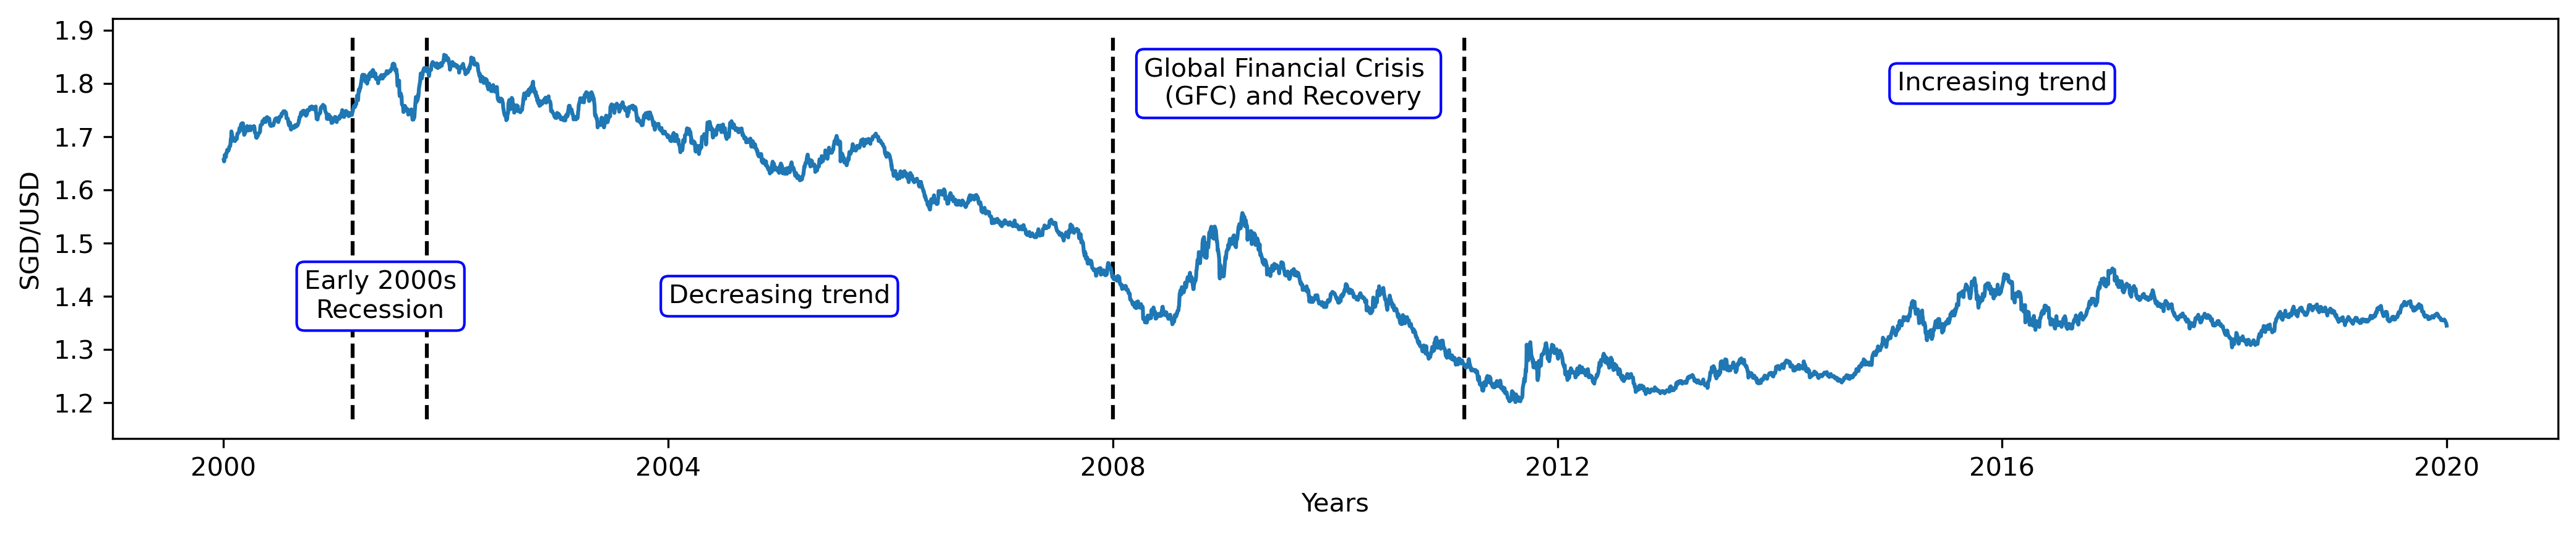

In [4]:
plt.plot(df.Date, df.SGD)

min_h, max_h = plt.ylim()[0], plt.ylim()[1]
plt.vlines(datetime.datetime(2001,3,1), min_h, max_h, colors='black', linestyles='dashed');
plt.vlines(datetime.datetime(2001,11,1), min_h, max_h, colors='black', linestyles='dashed');
plt.vlines(datetime.datetime(2008,1,1), min_h, max_h, colors='black', linestyles='dashed');
plt.vlines(datetime.datetime(2011,3,1), min_h, max_h, colors='black', linestyles='dashed');

plt.text(datetime.datetime(2001,6,1), 1.4, 'Early 2000s\nRecession',
             ha='center', va='center', bbox=dict(fc='white', ec='b', boxstyle='round'));
plt.text(datetime.datetime(2005,1,1), 1.4, 'Decreasing trend',
             ha='center', va='center', bbox=dict(fc='white', ec='b', boxstyle='round'));
plt.text(datetime.datetime(2009,8,1), 1.8, 'Global Financial Crisis \n (GFC) and Recovery',
             ha='center', va='center', bbox=dict(fc='white', ec='b', boxstyle='round'));
plt.text(datetime.datetime(2016,1,1), 1.8, 'Increasing trend',
             ha='center', va='center', bbox=dict(fc='white', ec='b', boxstyle='round'));
plt.xlabel('Years')
plt.ylabel('SGD/USD')
plt.show()

## Grouping by week

The dataset contains `SGD` and `YUAN` rates against `USD` on a daily basis (weekdays). We will resample them on a weekly basis. 

This will further condense the length of the dataset from 5019 to 1044, as well as evaluate the time series models on a weekly evaluation window.

In [5]:
df_week = df.set_index('Date').resample('W', label='left').mean()  # label left for start date
df_week.index = df_week.index + pd.DateOffset(1)  # makes it starts at 2000-01-03 instead of 2000-01-02
df_week

,SGD,YUAN
Date,,
2000-01-03,1.658760,8.279720
2000-01-10,1.669000,8.279600
2000-01-17,1.676575,8.279475
2000-01-24,1.693440,8.278420
2000-01-31,1.696800,8.277860
...,...,...
2019-12-02,1.362880,7.045420
2019-12-09,1.357380,7.019020
2019-12-16,1.354860,7.001540


The plot of SGD/USD is plotted again by weekly basis for sanity check.

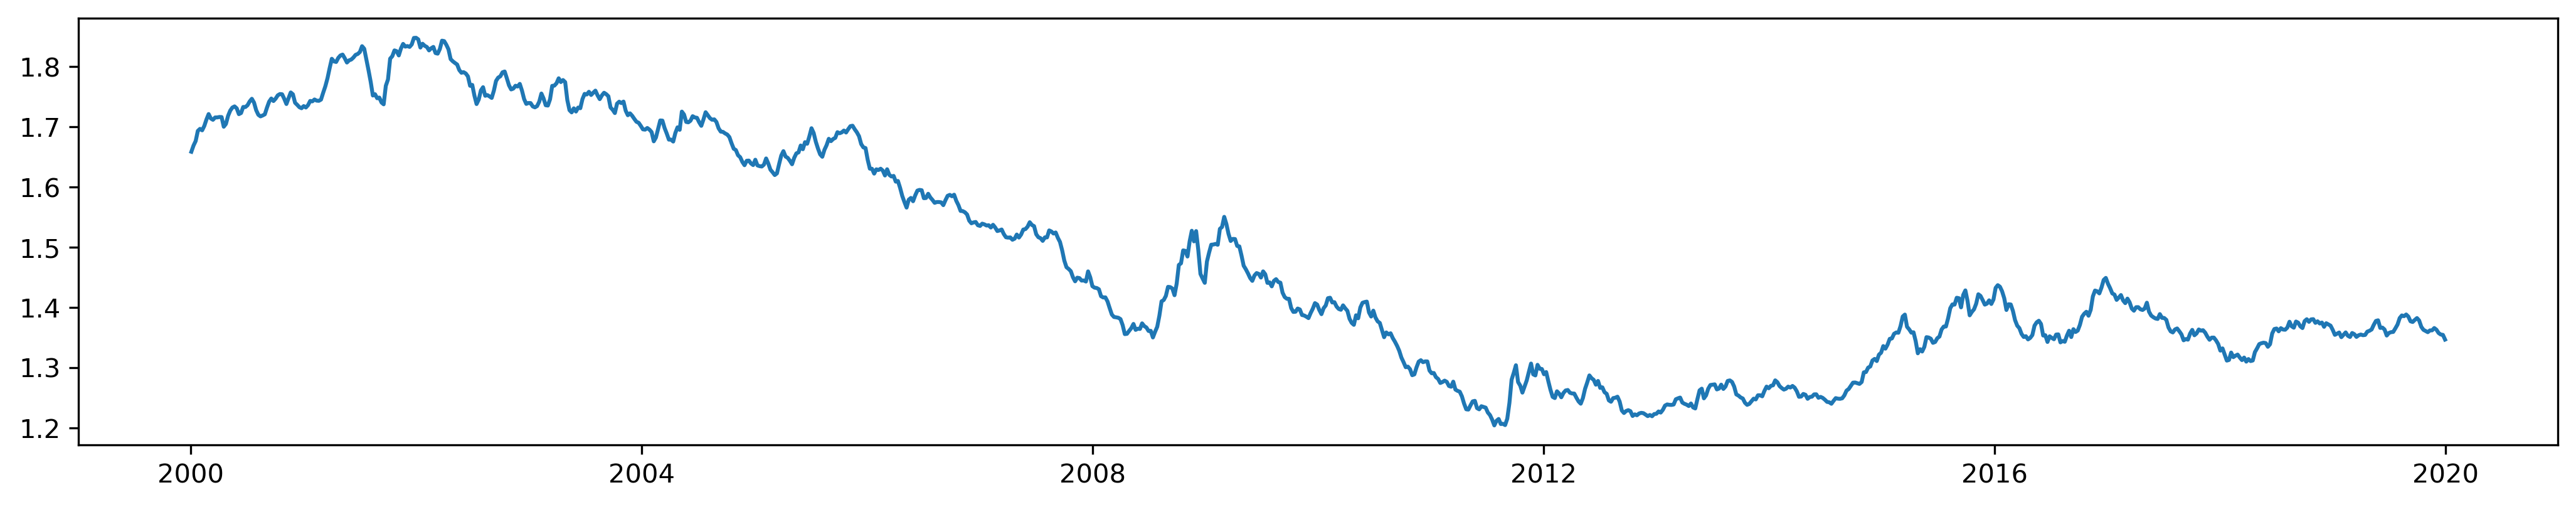

In [6]:
df_SGD = df_week[['SGD']]  # focus on SGD first
plt.plot(df_SGD)

# 2. Time Series Analysis
## Seasonal Decomposition

The decomposition technique is used deconstruct the time series data into several component for visualization of time series characteristics. 

The period is chosen as 1 year, around 52 weeks. We will perform the decomposition using the multiplicative model as the trend and seasonal variation vary over time.

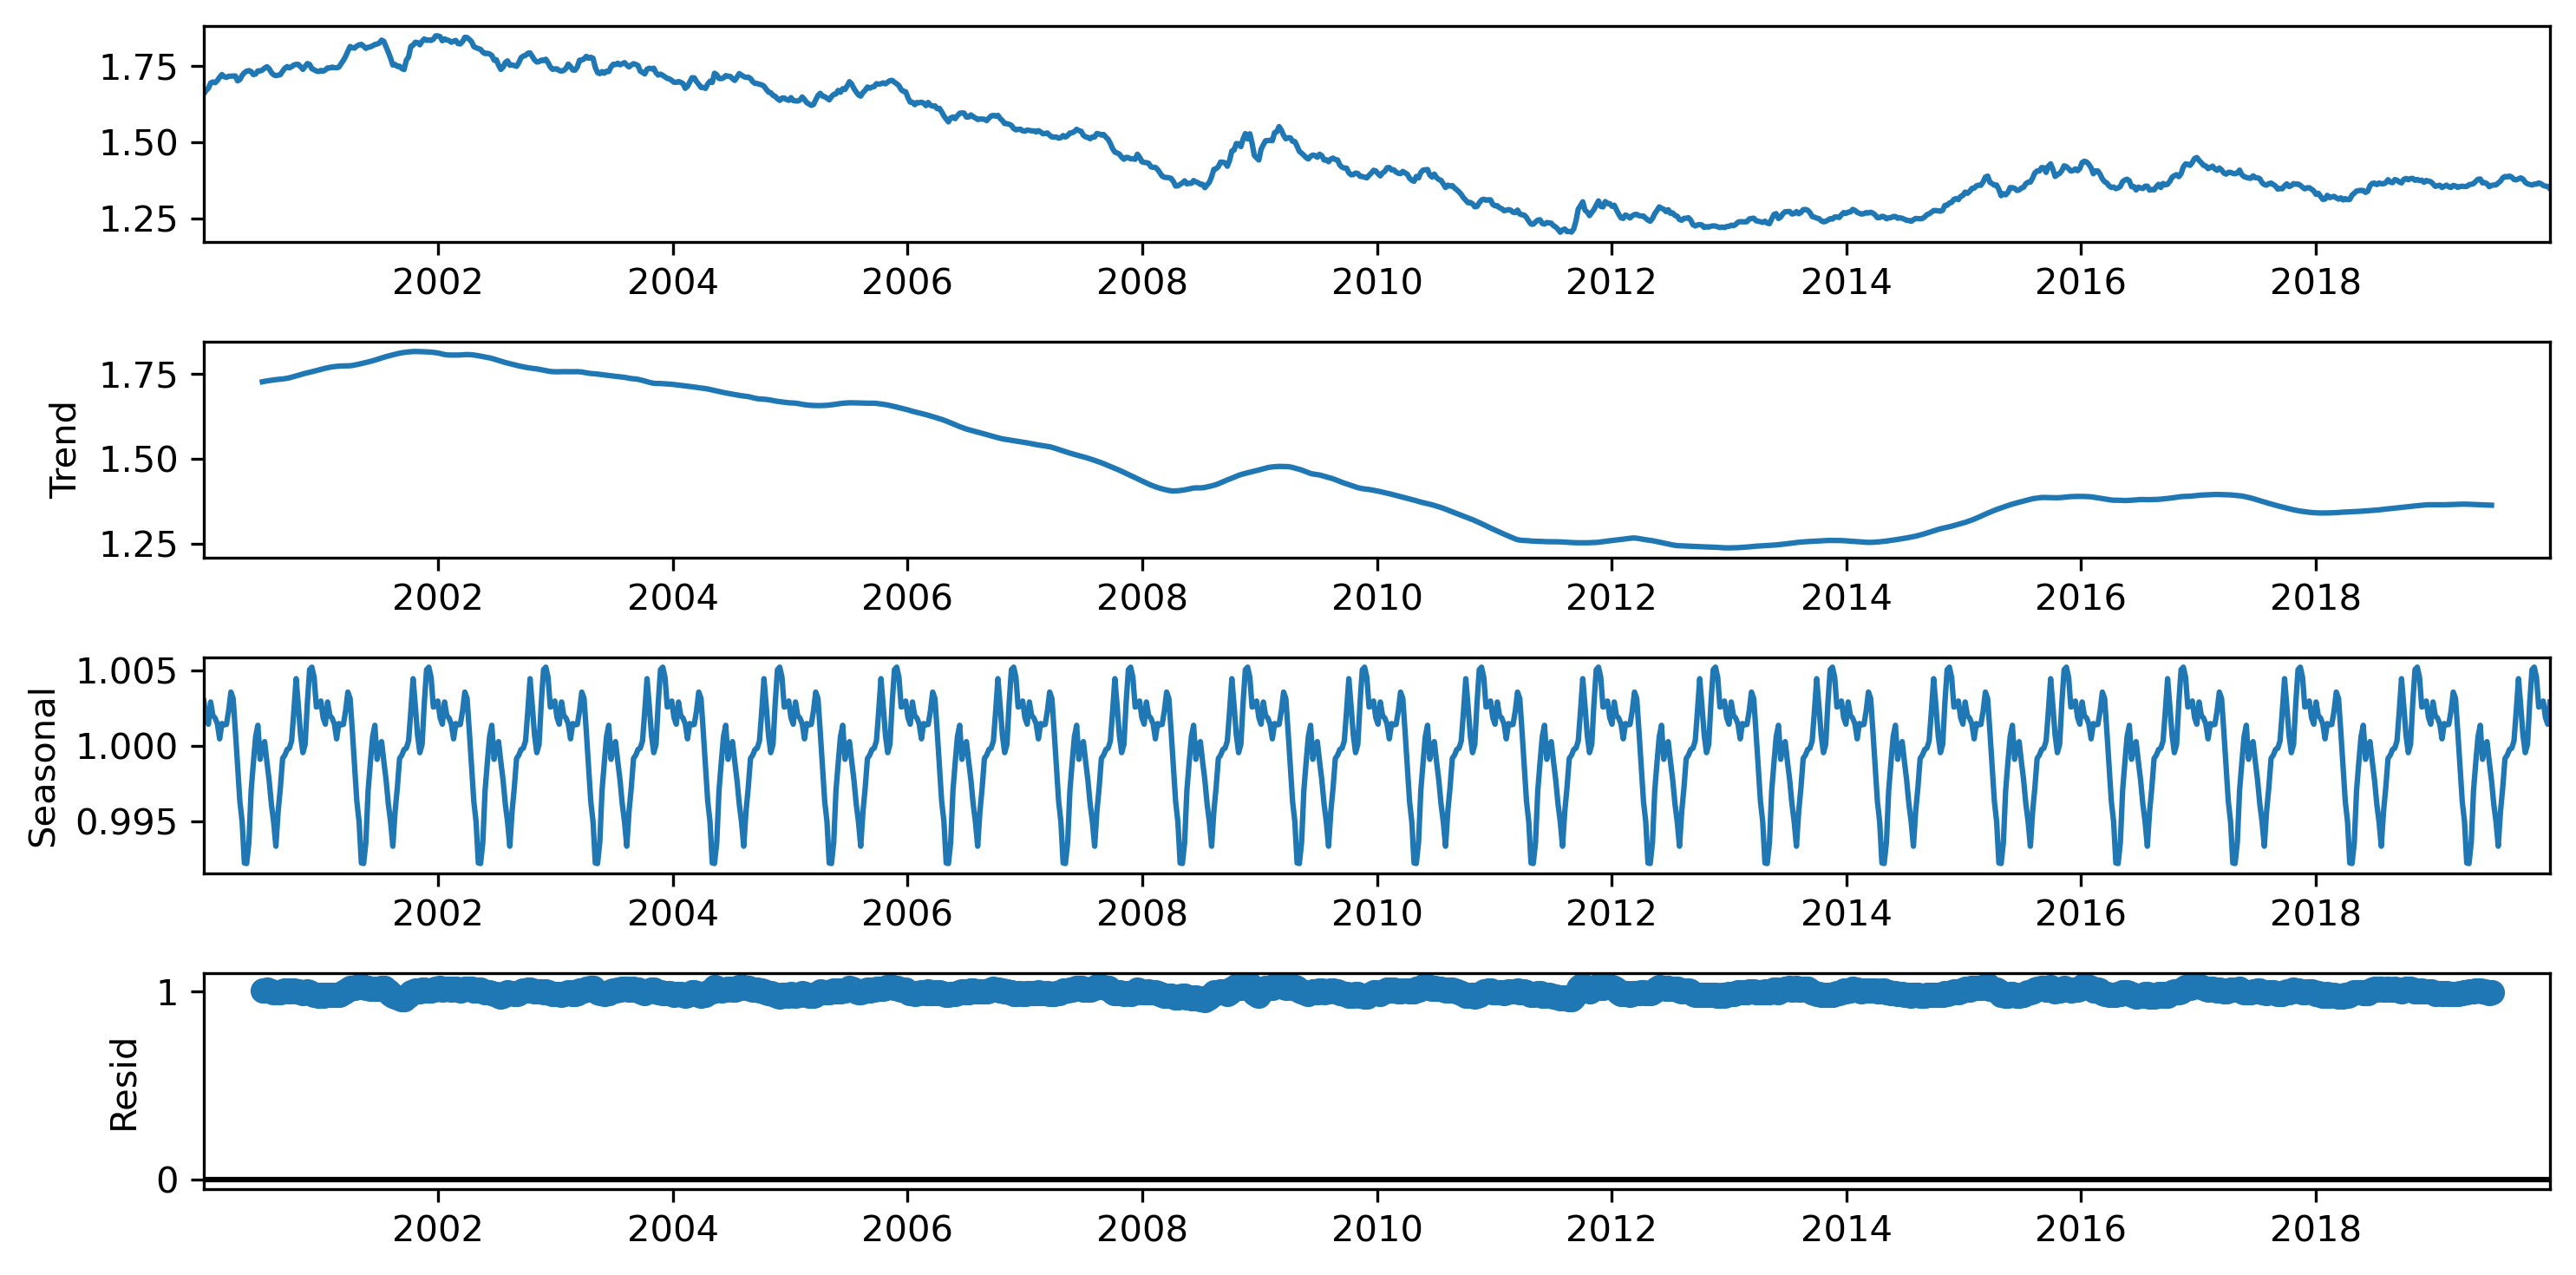

In [7]:
rcParams['figure.figsize'] = 10, 5
decomposition = sm.tsa.seasonal_decompose(df_SGD, model='multiplicative', period=52) 
fig = decomposition.plot()

#### Findings
- Trend: The trend component is an decreasing curve which seems to reach a plateau and an eventual increase at the end.
- Seasonality: The seasonal component cycles on a yearly basis, with its peak around the end of each year.
- Residuals: The resisdual component tends around the value of 1. Makes sense since we are using the multiplicative model.

## Stationarity Test

ARIMA models can be applied only in stationary data. That means that we do not want to have a trend in time. If the time series has a trend, then it is non-stationary and we need to apply differencing to transform it into stationary.

We are going to use rolling statistics and Dickey-Fuller test to check the stationarity of the time series.

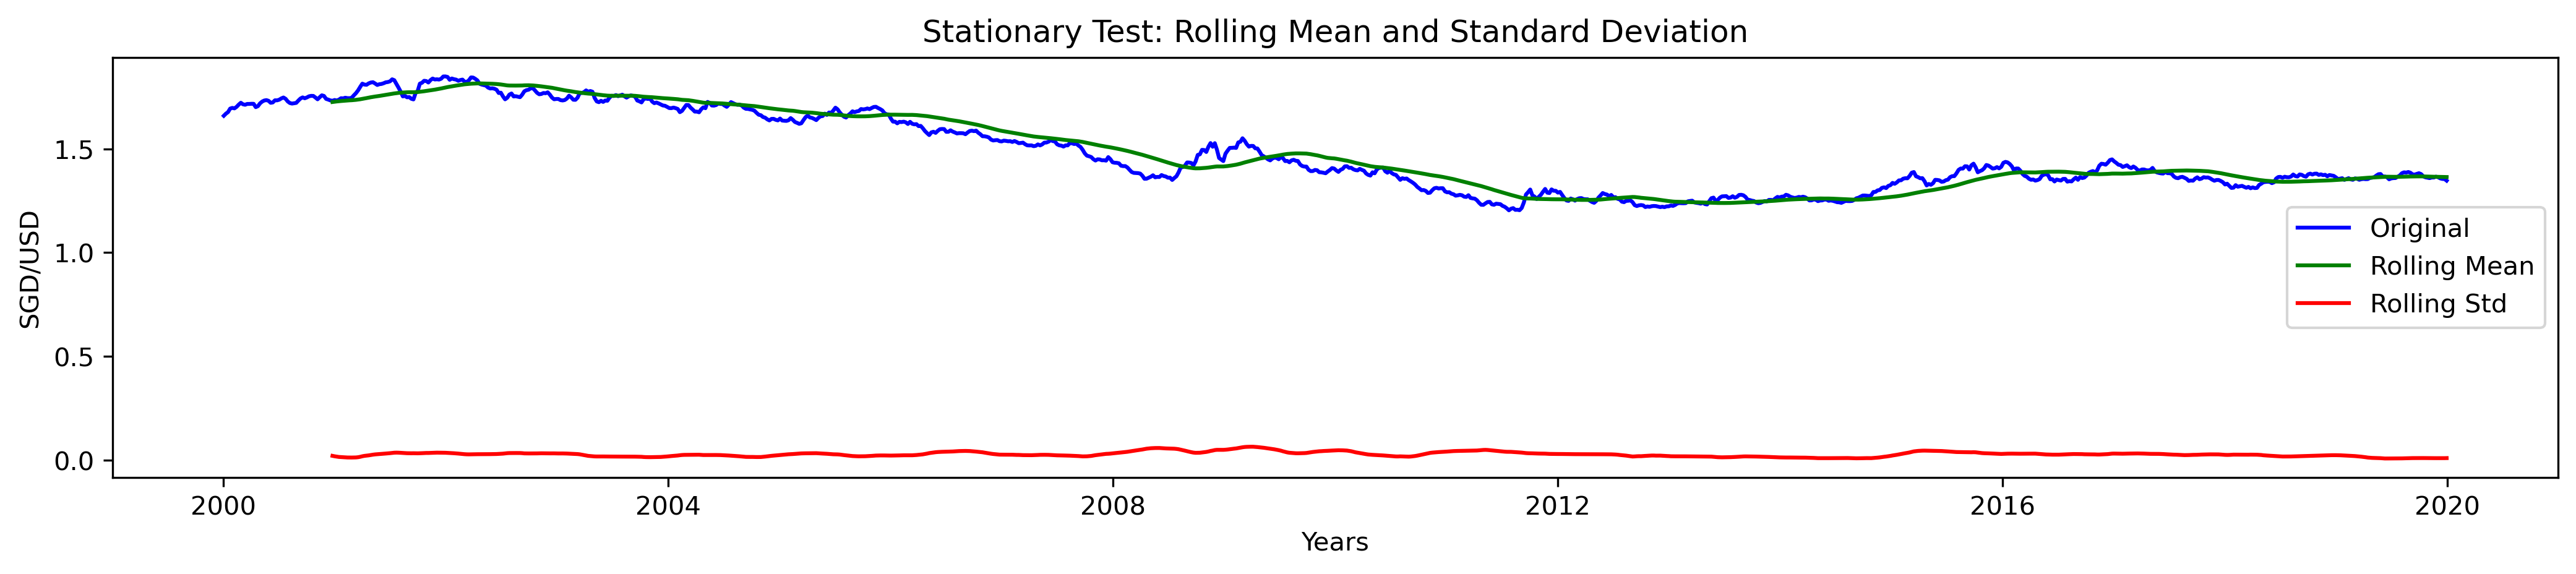

Results of Dickey-Fuller Test
Test Statistic                   -1.121548
p-value                           0.706403
#Lags Used                        5.000000
Number of Observations Used    1038.000000
Critical Value (1%)              -3.436666
Critical Value (5%)              -2.864328
Critical Value (10%)             -2.568255
dtype: float64


In [8]:
plt.rcParams.update({'figure.figsize': (17, 3), 'figure.dpi':300})
def stationarity_test(timeseries):
    # Get rolling statistics for window = 52 i.e. yearly statistics
    rolling_mean = timeseries.rolling(window = 52).mean()
    rolling_std = timeseries.rolling(window = 52).std()
    
    # Plot rolling statistic
    plt.xlabel('Years')
    plt.ylabel('SGD/USD')    
    plt.title('Stationary Test: Rolling Mean and Standard Deviation')
    plt.plot(timeseries, color= 'blue', label= 'Original')
    plt.plot(rolling_mean, color= 'green', label= 'Rolling Mean')
    plt.plot(rolling_std, color= 'red', label= 'Rolling Std')   
    plt.legend()
    plt.show()
    
    # Dickey-Fuller test
    print('Results of Dickey-Fuller Test')
    df_test = adfuller(timeseries)
    df_output = pd.Series(df_test[0:4], 
                          index = ['Test Statistic', 'p-value', 
                                   '#Lags Used', 'Number of Observations Used'])
    for key, value in df_test[4].items():
        df_output['Critical Value (%s)' %key] = value
    print(df_output)

stationarity_test(df_SGD) # 0.706403

By visual inspection, we observe that the time series is not a stationary series. We will look at the rolling statistics and Duckey Fuller test results for a sanity check

- Rolling statistics: Standard deviation has very less variation but mean has a decreasing trend.
- Duckey Fuller Test: Test statistic is above the critical values (1%).


## Differencing

To transform the series using 'Differencing' we will use the diff() method of pandas.

We will perform 1st differencing and 2nd differencing and compare the results.

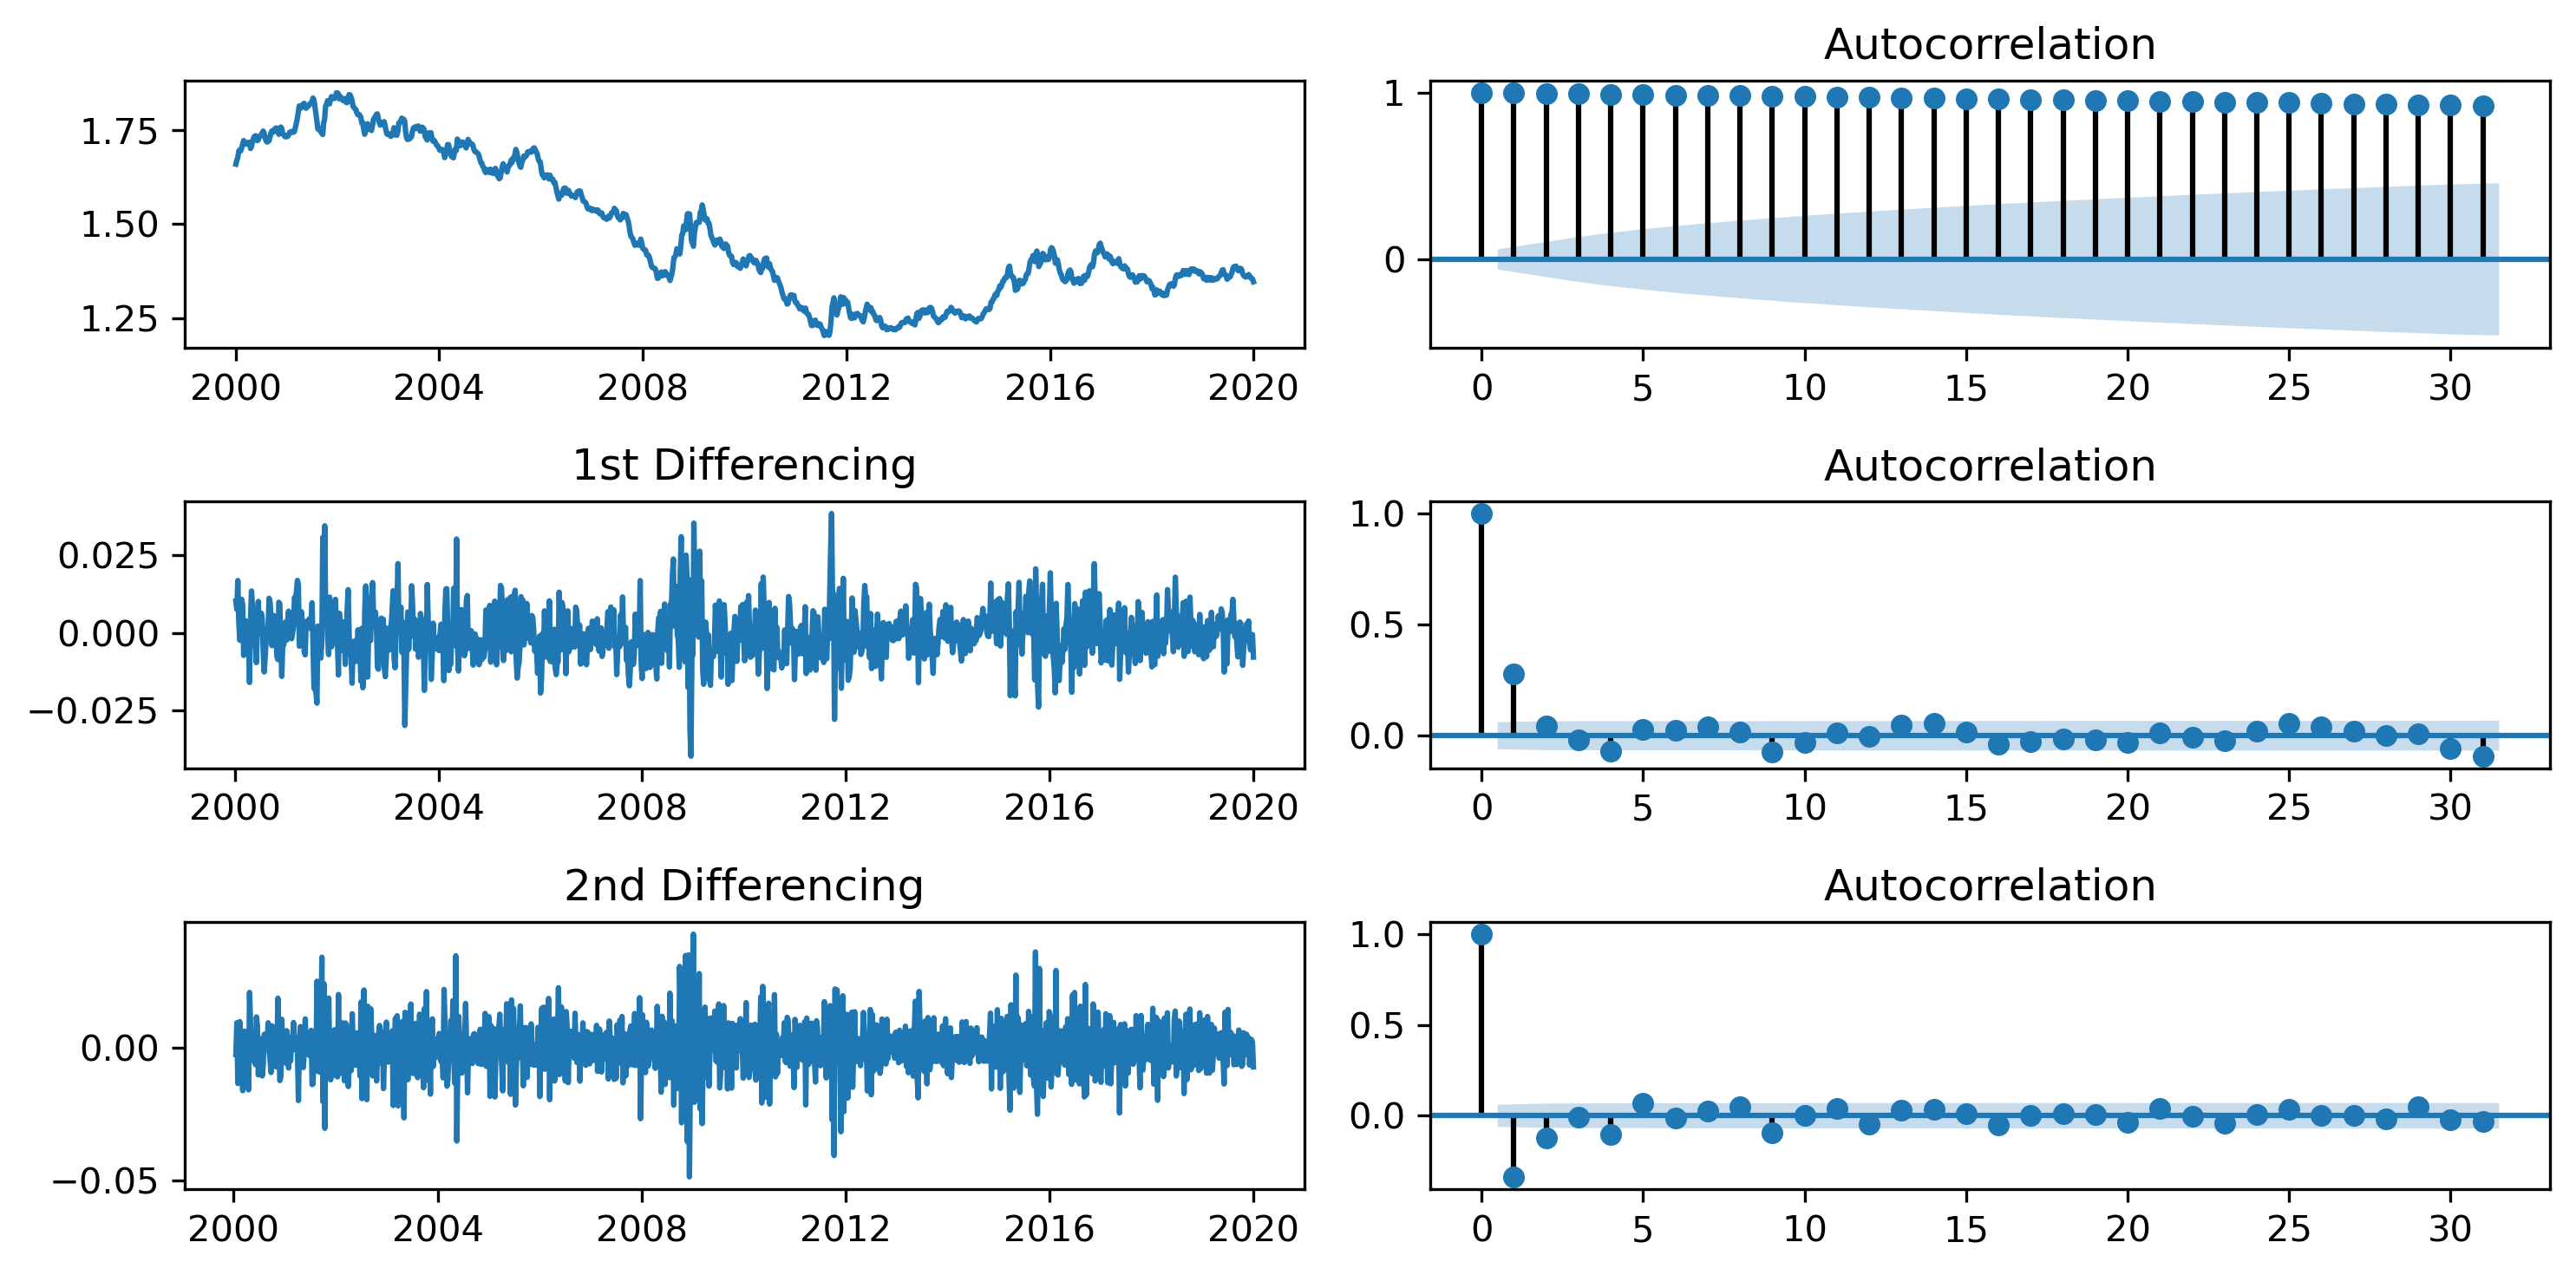

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(10,5))
axes[0, 0].plot(df_SGD)
plot_acf(df_SGD, ax=axes[0, 1])

# # 1st Differencing
axes[1, 0].plot(df_SGD.diff())
plot_acf(df_SGD.diff().dropna(), ax=axes[1, 1])
axes[1, 0].set_title('1st Differencing')

# # 2nd Differencing
axes[2, 0].plot(df_SGD.diff().diff())
plot_acf(df_SGD.diff().diff().dropna(), ax=axes[2, 1])
axes[2, 0].set_title('2nd Differencing')

plt.tight_layout()

The timeseries is stationary at `d = 1` where only the first lag is above the significance level. We will use `d = 1`.

We will perform stationarity test for `d = 1`.

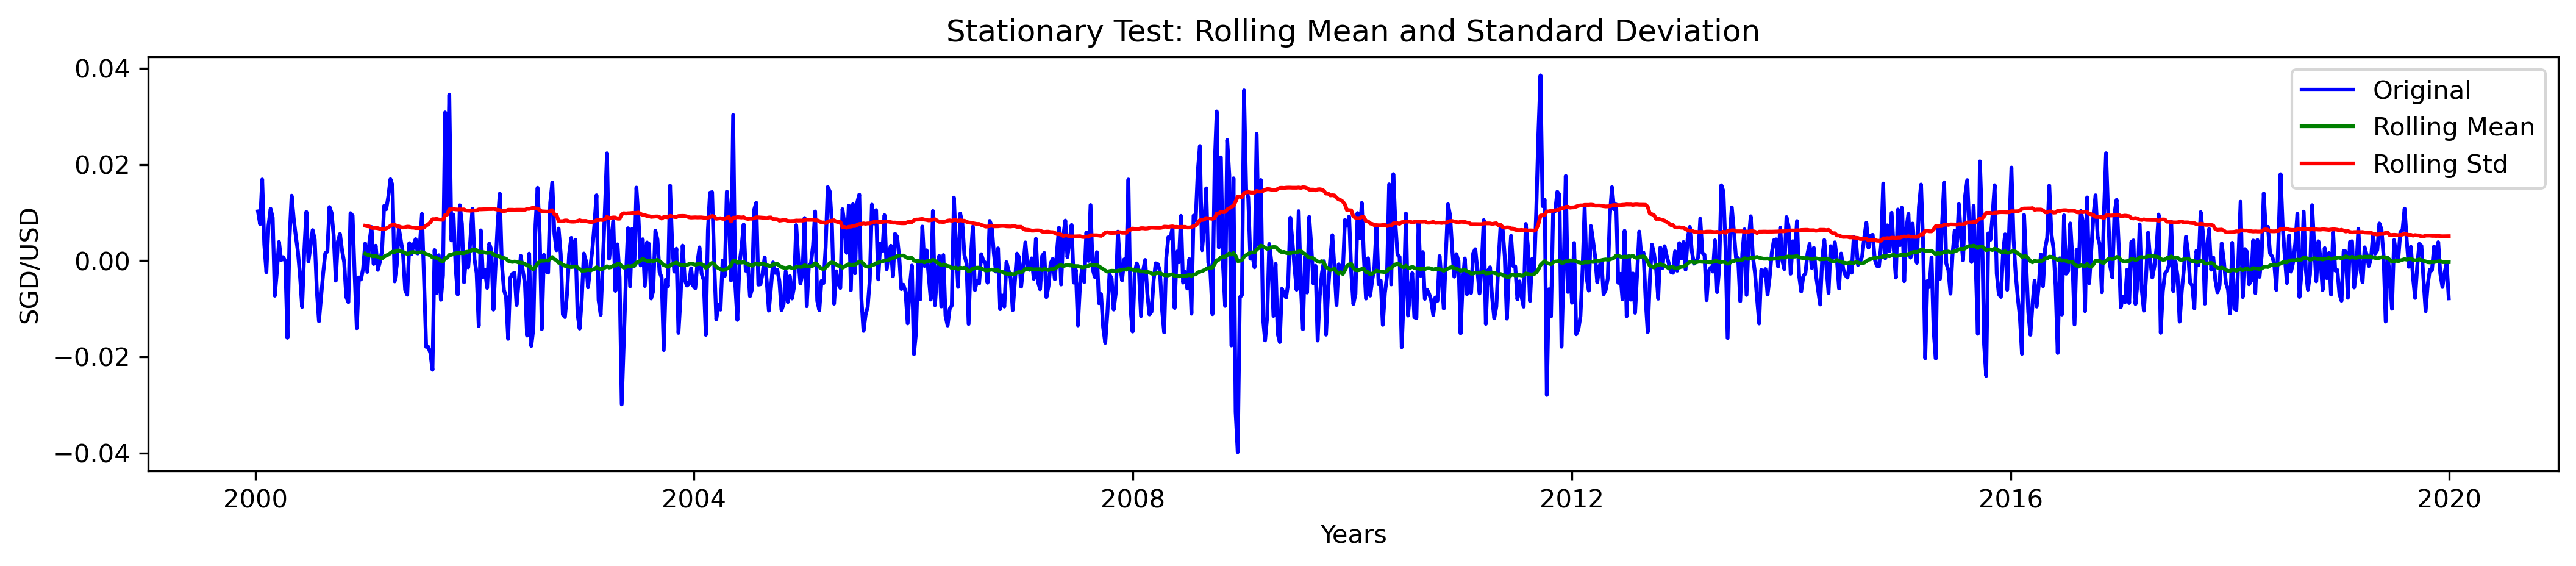

Results of Dickey-Fuller Test
Test Statistic                -1.353681e+01
p-value                        2.558230e-25
#Lags Used                     4.000000e+00
Number of Observations Used    1.038000e+03
Critical Value (1%)           -3.436666e+00
Critical Value (5%)           -2.864328e+00
Critical Value (10%)          -2.568255e+00
dtype: float64


In [10]:
stationarity_test(df_SGD.diff().dropna()) # 2.558230e-25

The rolling mean and standard deviation values are okay now. The p-value is less than 0.05, and the test statistic is less than the critical value (1%). The time series is now stationary.

## ACF and PACF Plots

ARIMA model requires three parameters, 'p' for the order of Auto-Regressive (AR) part, 'q' for the order of Moving Average (MA) part and 'd' for the order of integrated part. 

The Auto Correlation Function (ACF) plot and PCF (Partial Auto Correlation Function) plot can help us determine the value for 'p' and 'q'. 

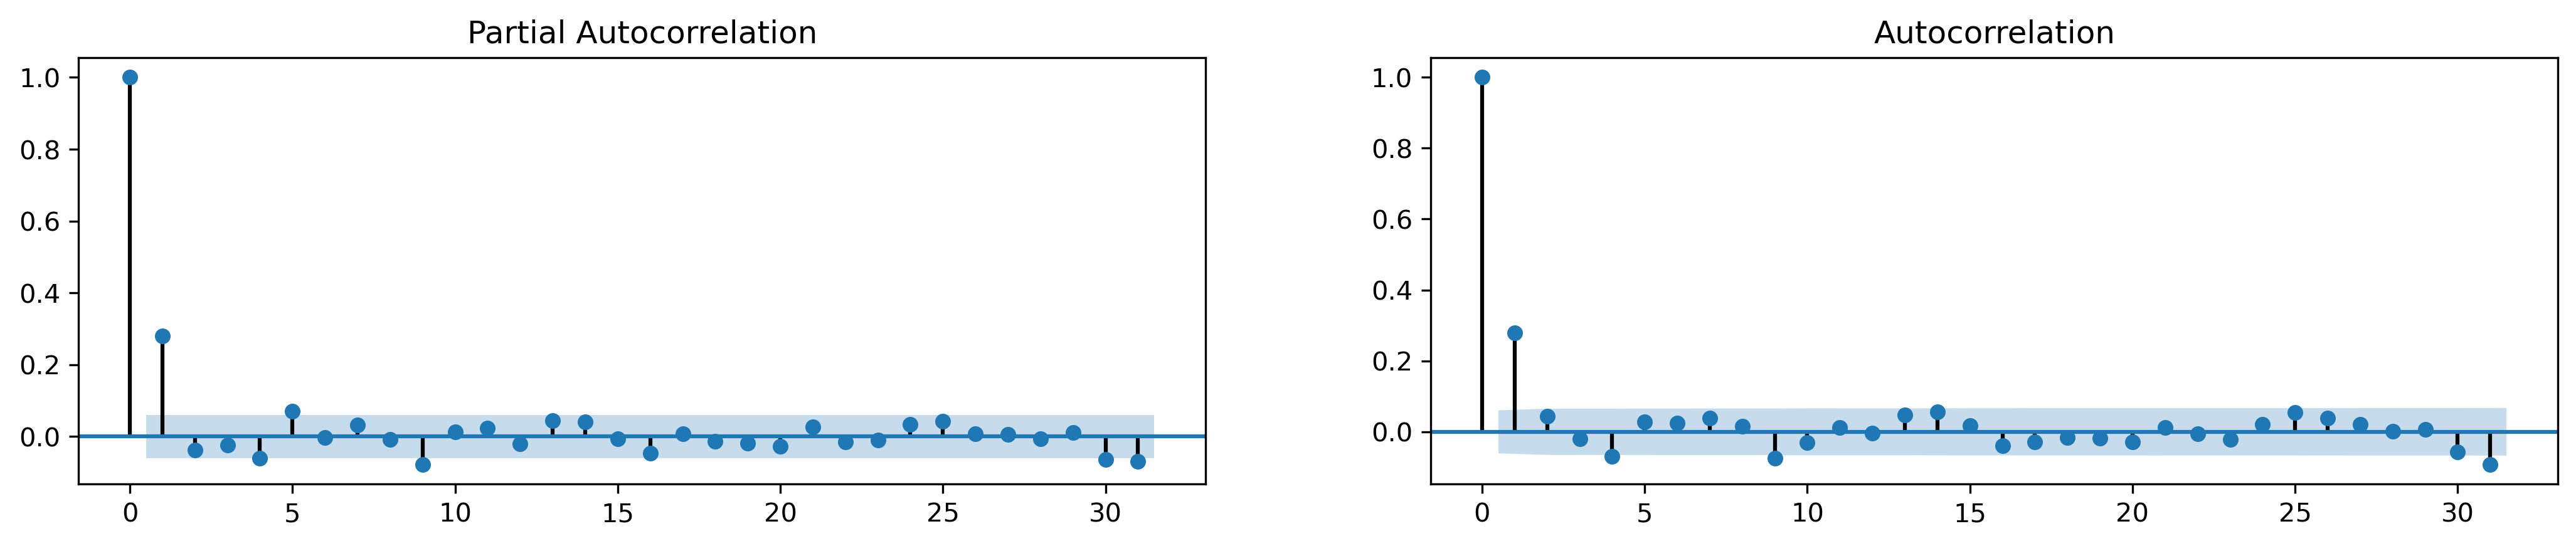

In [11]:
fig, axes = plt.subplots(1, 2)
plot_pacf(df_SGD.diff().dropna(), ax=axes[0])
plot_acf(df_SGD.diff().dropna(), ax=axes[1])
plt.show()

From the plots, `p = 2` and `q = 2`.

# 3. SGD/USD Time Series Forecast
## ARIMA (AutoRegressive Integrated Moving Averages)

From [DigitalOcean](https://www.digitalocean.com/community/tutorials/a-guide-to-time-series-forecasting-with-arima-in-python-3),
> One of the most common methods used in time series forecasting is known as the ARIMA model, which stands for AutoregRessive Integrated Moving Average. ARIMA is a model that can be fitted to time series data in order to better understand or predict future points in the series.

> There are three distinct integers (p, d, q) that are used to parametrize ARIMA models. Because of that, ARIMA models are denoted with the notation ARIMA(p, d, q). Together these three parameters account for seasonality, trend, and noise in datasets:

> - p is the auto-regressive part of the model. It allows us to incorporate the effect of past values into our model. Intuitively, this would be similar to stating that it is likely to be warm tomorrow if it has been warm the past 3 days.
> - d is the integrated part of the model. This includes terms in the model that incorporate the amount of differencing (i.e. the number of past time points to subtract from the current value) to apply to the time series. Intuitively, this would be similar to stating that it is likely to be same temperature tomorrow if the difference in temperature in the last three days has been very small.
> - q is the moving average part of the model. This allows us to set the error of our model as a linear combination of the error values observed at previous time points in the past.


When evaluating and comparing statistical models fitted with different parameters, each can be ranked against one another based on how well it fits the data or its ability to accurately predict future data points. We will use the AIC (Akaike Information Criterion) value, which is conveniently returned with ARIMA models fitted using statsmodels. The AIC measures how well a model fits the data while taking into account the overall complexity of the model. A model that fits the data very well while using lots of features will be assigned a larger AIC score than a model that uses fewer features to achieve the same goodness-of-fit. Therefore, we are interested in finding the model that yields the lowest AIC value.

In [12]:
model = ARIMA(df_SGD, order=(1,1,1))  # base model
model_fit = model.fit(disp=0)
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             ARIMA Model Results                              
==============================================================================
Dep. Variable:                  D.SGD   No. Observations:                 1043
Model:                 ARIMA(1, 1, 1)   Log Likelihood                3545.290
Method:                       css-mle   S.D. of innovations              0.008
Date:                Sun, 20 Feb 2022   AIC                          -7082.580
Time:                        14:45:52   BIC                          -7062.781
Sample:                    01-10-2000   HQIC                         -7075.070
                         - 12-30-2019                                         
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0003      0.000     -0.886      0.376      -0.001       0.000
ar.L1.D.SGD     0.1689      0.108      1.563      0.118      -0.043       0.381
ma.L1.D.SGD     0.1203      0.109      1.105      0.269      -0.093       0.334
                                    Roots                                    
=============================================================================
                  Real          Imaginary           Modulus         Frequency
-----------------------------------------------------------------------------
AR.1            5.9202           +0.0000j            5.9202            0.0000
MA.1           -8.3112           +0.0000j            8.3112            0.5000
-----------------------------------------------------------------------------
"""

The base ARIMA model for (1, 1, 1) has a `AIC` of `-7082.58`. The coef column shows the weight (i.e. importance) of each feature and how each one impacts the time series. The `P>|z|` column informs us of the significance of each feature weight. In this case, each weight has a p-value higher than `0.05`.

In [13]:
model = ARIMA(df_SGD, order=(2,1,2))  # based on chosen p, d, q
model_fit = model.fit(disp=0)
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             ARIMA Model Results                              
==============================================================================
Dep. Variable:                  D.SGD   No. Observations:                 1043
Model:                 ARIMA(2, 1, 2)   Log Likelihood                3545.464
Method:                       css-mle   S.D. of innovations              0.008
Date:                Sun, 20 Feb 2022   AIC                          -7078.928
Time:                        14:45:53   BIC                          -7049.229
Sample:                    01-10-2000   HQIC                         -7067.664
                         - 12-30-2019                                         
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0003      0.000     -1.020      0.308      -0.001       0.000
ar.L1.D.SGD     1.1416      0.130      8.795      0.000       0.887       1.396
ar.L2.D.SGD    -0.1832      0.108     -1.704      0.088      -0.394       0.028
ma.L1.D.SGD    -0.8527      0.131     -6.507      0.000      -1.110      -0.596
ma.L2.D.SGD    -0.0978      0.110     -0.891      0.373      -0.313       0.117
                                    Roots                                    
=============================================================================
                  Real          Imaginary           Modulus         Frequency
-----------------------------------------------------------------------------
AR.1            1.0543           +0.0000j            1.0543            0.0000
AR.2            5.1775           +0.0000j            5.1775            0.0000
MA.1            1.0471           +0.0000j            1.0471            0.0000
MA.2           -9.7678           +0.0000j            9.7678            0.5000
-----------------------------------------------------------------------------
"""

The model with parameters based on the ACF and PACF plots have a higher AIC score than the base model. We will use a grid search to identify the set of parameters that produces the best fitting model to our time series data, optimising for the lowest AIC score.

In [14]:
import itertools

p = [0, 1, 2, 4, 6]
d = range(0, 3)
q = range(0, 3)
optimal_params = None
min_aic = float('inf')

pdq = list(itertools.product(p, d, q))

for param in pdq:
    try:
        model = ARIMA(df_SGD, order=param)
        results = model.fit()
        if results.aic < min_aic:
            optimal_params = param
        min_aic = min(min_aic, results.aic)
        
        print('ARIMA{} - AIC:{}'.format(param, results.aic))
    except:
        continue

print(f'Best params: {optimal_params}, min_aic: {min_aic}')

ARIMA(0, 0, 0) - AIC:-514.353496129738
ARIMA(0, 0, 1) - AIC:-1911.4095435740187
ARIMA(0, 1, 0) - AIC:-7000.529577814435
ARIMA(0, 1, 1) - AIC:-7082.482916778277
ARIMA(0, 1, 2) - AIC:-7082.440420555085
ARIMA(0, 2, 0) - AIC:-6613.36596283092
ARIMA(0, 2, 1) - AIC:-6985.158483134108
ARIMA(0, 2, 2) - AIC:-7066.272454682017
ARIMA(1, 0, 0) - AIC:-6998.563578917281
ARIMA(1, 0, 1) - AIC:-7081.2262063813705
ARIMA(1, 0, 2) - AIC:-7081.323829665824
ARIMA(1, 1, 0) - AIC:-7083.306410136896
ARIMA(1, 1, 1) - AIC:-7082.580256512991
ARIMA(1, 1, 2) - AIC:-7080.605997387518
ARIMA(1, 2, 0) - AIC:-6736.486380313219
ARIMA(1, 2, 1) - AIC:-7062.081499953034
ARIMA(1, 2, 2) - AIC:-7060.775729037494
ARIMA(2, 0, 0) - AIC:-7082.325686634016
ARIMA(2, 0, 1) - AIC:-7081.499202389907
ARIMA(2, 0, 2) - AIC:-7079.521739580305
ARIMA(2, 1, 0) - AIC:-7082.730728606291
ARIMA(2, 1, 1) - AIC:-7081.634766226669
ARIMA(2, 1, 2) - AIC:-7078.92823493172
ARIMA(2, 2, 0) - AIC:-6809.670838074226
ARIMA(2, 2, 1) - AIC:-7064.098761762669
A

In [15]:
model = ARIMA(df_SGD, order=optimal_params)  # based on grid search
fitted_ARIMA = model.fit(disp=-1)  
fitted_ARIMA.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             ARIMA Model Results                              
==============================================================================
Dep. Variable:                  D.SGD   No. Observations:                 1043
Model:                 ARIMA(4, 1, 2)   Log Likelihood                3551.040
Method:                       css-mle   S.D. of innovations              0.008
Date:                Sun, 20 Feb 2022   AIC                          -7086.081
Time:                        14:46:26   BIC                          -7046.482
Sample:                    01-10-2000   HQIC                         -7071.061
                         - 12-30-2019                                         
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0003      0.000     -0.924      0.355      -0.001       0.000
ar.L1.D.SGD    -0.8022      0.167     -4.796      0.000      -1.130      -0.474
ar.L2.D.SGD    -0.3754      0.143     -2.623      0.009      -0.656      -0.095
ar.L3.D.SGD     0.1518      0.060      2.541      0.011       0.035       0.269
ar.L4.D.SGD    -0.0936      0.033     -2.801      0.005      -0.159      -0.028
ma.L1.D.SGD     1.0978      0.166      6.601      0.000       0.772       1.424
ma.L2.D.SGD     0.6647      0.169      3.936      0.000       0.334       0.996
                                    Roots                                    
=============================================================================
                  Real          Imaginary           Modulus         Frequency
-----------------------------------------------------------------------------
AR.1           -0.8134           -0.8259j            1.1592           -0.3738
AR.2           -0.8134           +0.8259j            1.1592            0.3738
AR.3            1.6243           -2.3054j            2.8201           -0.1523
AR.4            1.6243           +2.3054j            2.8201            0.1523
MA.1           -0.8258           -0.9069j            1.2265           -0.3675
MA.2           -0.8258           +0.9069j            1.2265            0.3675
-----------------------------------------------------------------------------
"""

The above model has the lowest AIC score, and the `P>|z|` for all the weights are below 0.05, so it is reasonable to retain all of them in our model.

We can plot the residuals of the model to have an idea on how well the model is fitted. 

The residuals are the difference between the original values and the predicted values from the model, and should be near zero mean and uniform variance. 

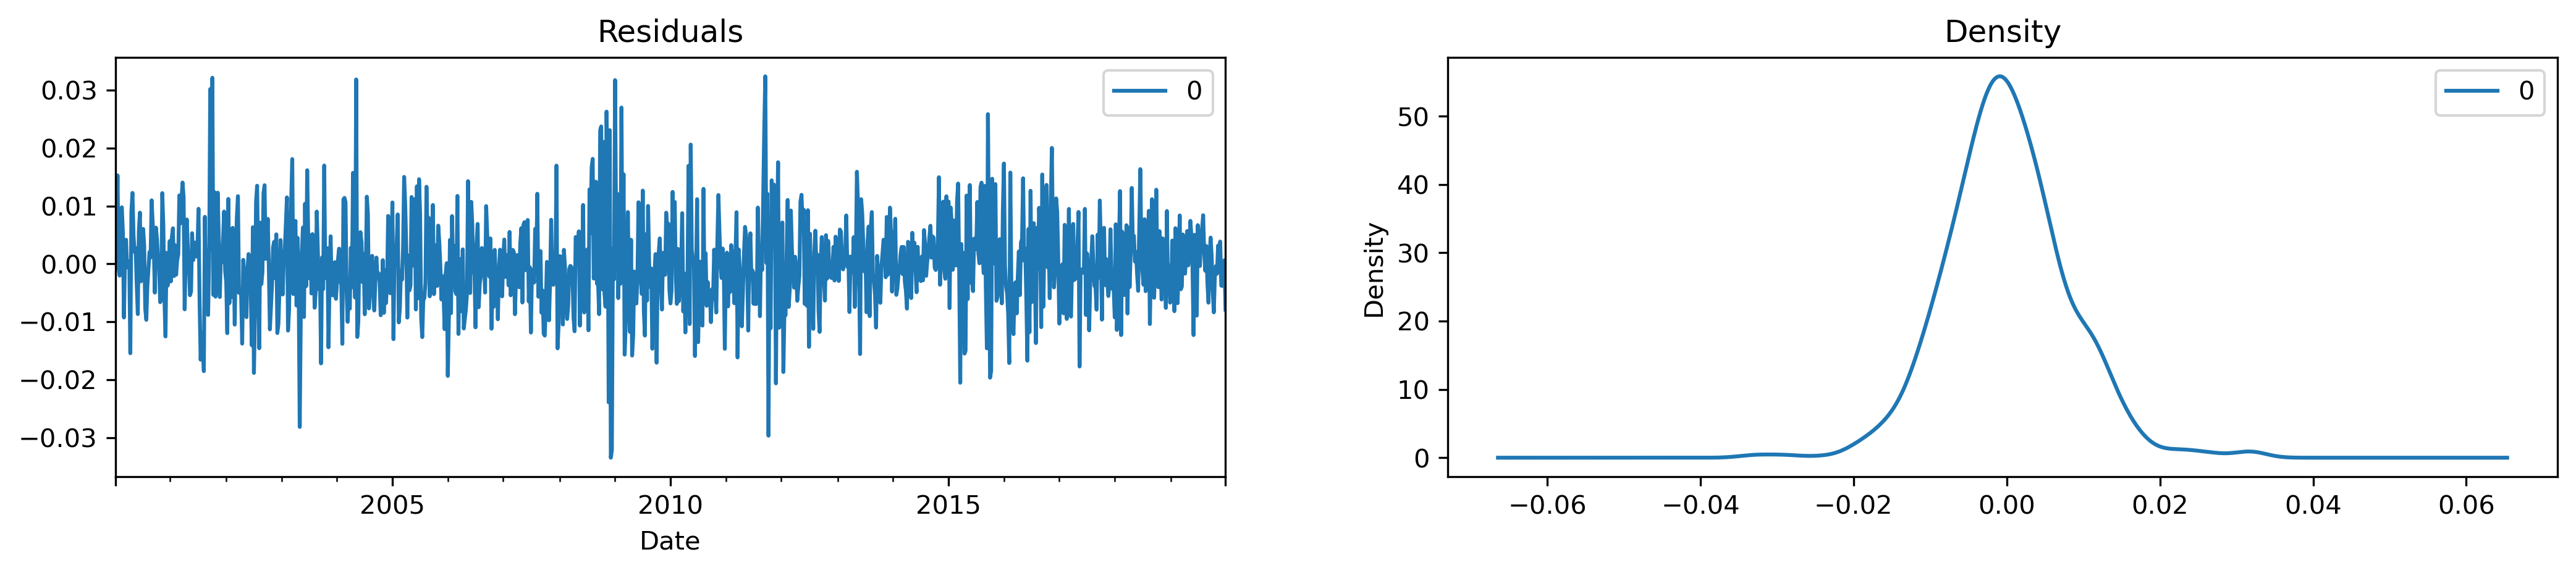

In [16]:
residuals = pd.DataFrame(fitted_ARIMA.resid)
fig, ax = plt.subplots(1,2)
residuals.plot(title="Residuals", ax=ax[0])
residuals.plot(kind='kde', title='Density', ax=ax[1])
plt.show()

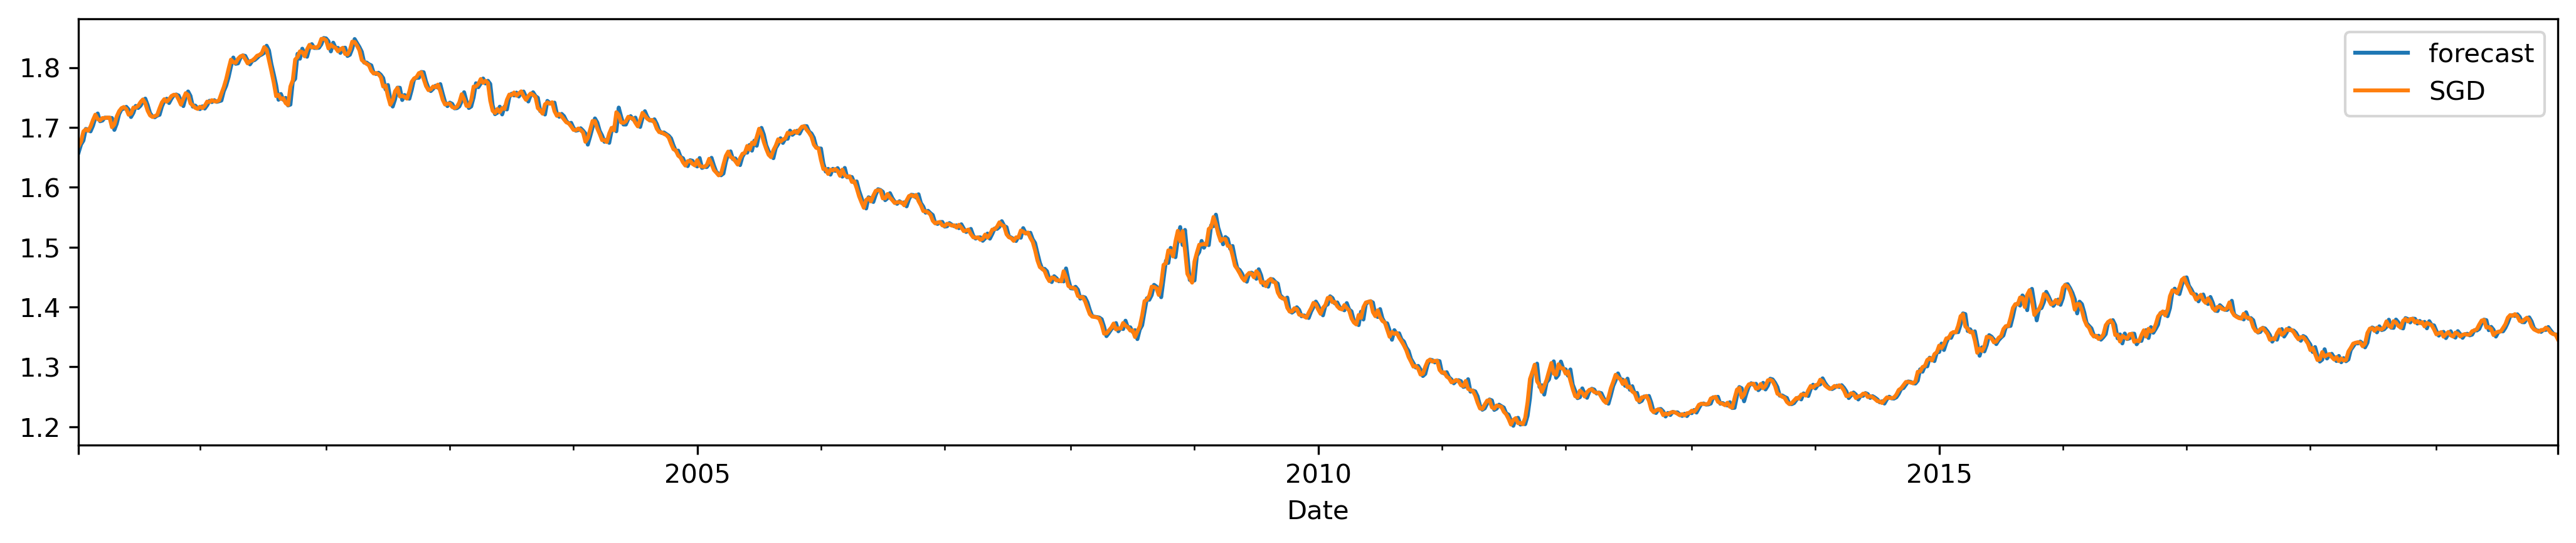

In [17]:
fitted_ARIMA.plot_predict(dynamic=False)
plt.show()

### Evaluation
The dataset will be split into train set and test set. The test will consist of 2019 data, while the rest of the data will be included in the training set.

In [18]:
train = df_SGD[df_SGD.index.year < 2019]
test = df_SGD[df_SGD.index.year == 2019]
len(train), len(test)

(992, 52)

Utils functions for plotting and evaluating model

In [19]:
def plot_forecast(fc, conf, train, test, ylim, zoom=5):
    # Make as pandas series
    fc_series = pd.Series(fc, index=test.index)
    lower_series = pd.Series(conf[:, 0], index=test.index)
    upper_series = pd.Series(conf[:, 1], index=test.index)

    # Plot
    fig, ax = plt.subplots()
    ax.plot(train, label='training')
    ax.plot(test, label='actual')
    ax.plot(fc_series, label='forecast')
    ax.fill_between(lower_series.index, lower_series, upper_series, 
                    color='k', alpha=.15)

    axins = zoomed_inset_axes(ax, zoom, loc='lower left') # zoom-factor
    axins.plot(test)
    axins.plot(fc_series)
    axins.set_ylim(*ylim)   
    plt.yticks(visible=False)
    plt.xticks(visible=False)
    mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

    ax.set_title('Forecast vs Actuals')
    ax.legend(loc='upper right', fontsize=8)
    plt.show()

    
def forecast_accuracy(forecast, actual):
    mape = np.mean(np.abs(forecast - actual)/np.abs(actual))  # MAPE
    me = np.mean(forecast - actual)             # ME
    mae = np.mean(np.abs(forecast - actual))    # MAE
    mpe = np.mean((forecast - actual)/actual)   # MPE
    rmse = np.mean((forecast - actual)**2)**.5  # RMSE
    corr = np.corrcoef(forecast, actual)[0,1]   # corr
    mins = np.amin(np.hstack([forecast[:,None], actual[:,None]]), axis=1)
    maxs = np.amax(np.hstack([forecast[:,None], actual[:,None]]), axis=1)
    minmax = 1 - np.mean(mins/maxs)             # minmax
    acf1 = acf(forecast-actual)[1]              # ACF1
    return({'mape':mape, 'me':me, 'mae': mae, 
            'mpe': mpe, 'rmse':rmse, 'acf1':acf1, 
            'corr':corr, 'minmax':minmax})

Typically, for comparing forecasts of two different series, the MAPE, Correlation and Min-Max Error can be used. Those three metrics are percentage errors that vary between 0 and 1. That way, you can judge how good is the forecast irrespective of the scale of the series.

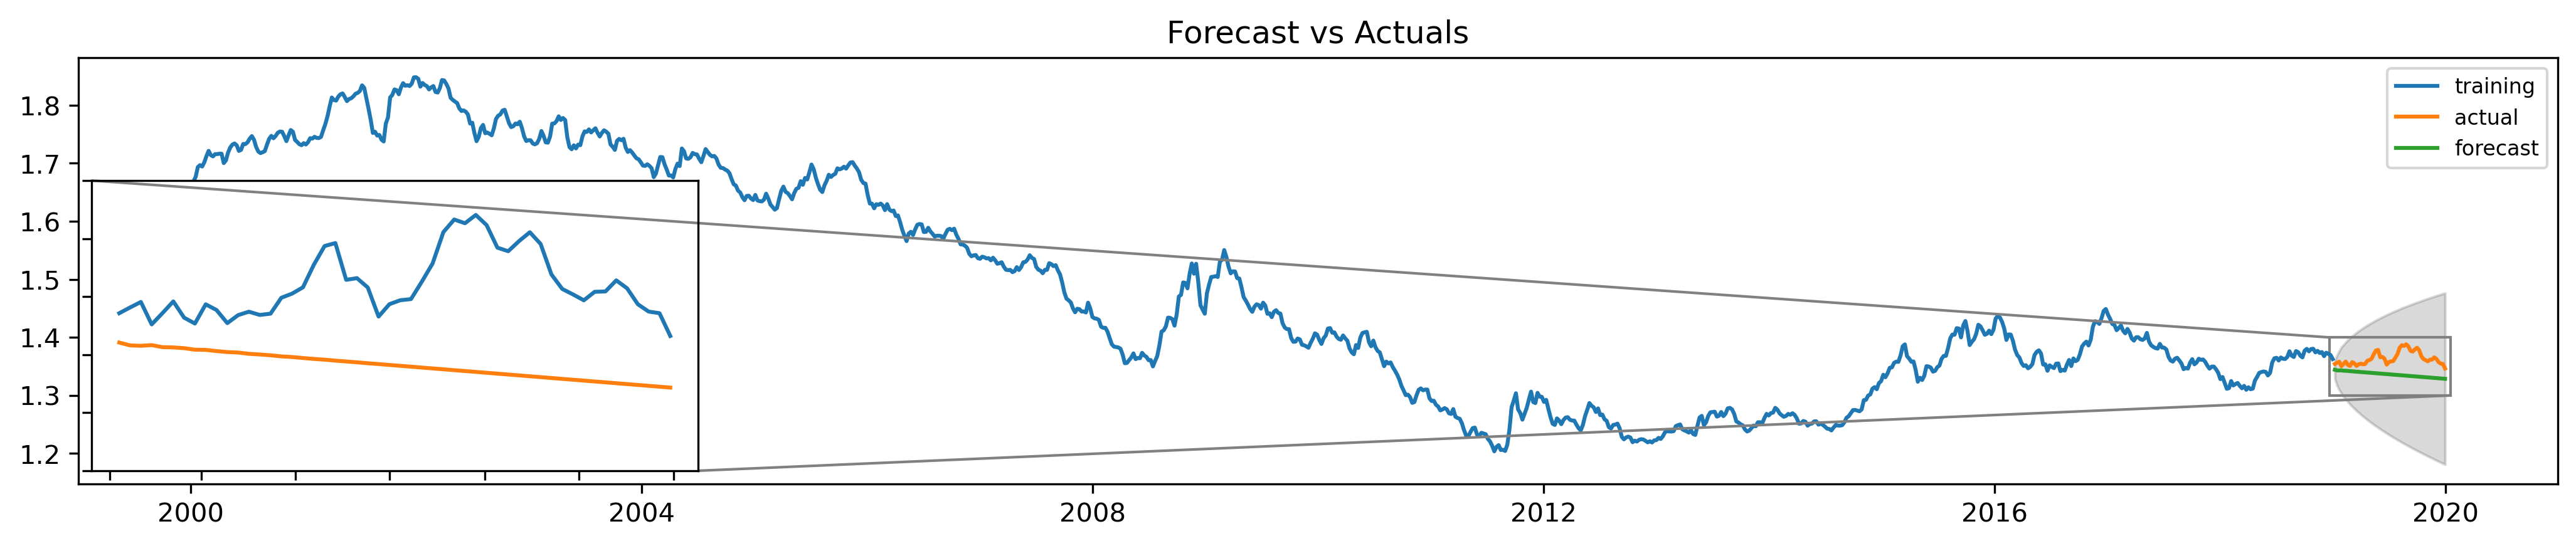

{'mape': 0.020122266632963133,
 'me': -0.027540767724283197,
 'mae': 0.027540767724283197,
 'mpe': -0.020122266632963133,
 'rmse': 0.030501566916783285,
 'acf1': 0.9072075219630139,
 'corr': -0.3324463389148825,
 'minmax': 0.020122266632963237}

In [20]:
fc, se, conf_week = fitted_ARIMA.forecast(len(test), alpha=0.05)  # 95% conf
plot_forecast(fc, conf_week, train, test, ylim=(1.30, 1.4))
results_arima = forecast_accuracy(fc, test.SGD)
results_arima

The ARIMA model achieves aournd 2.0% MAPE, implies the model is about 98.0% accurate in predicting the test values.

## SARIMA

The problem with plain ARIMA model is it does not support seasonality. If the time series has defined seasonality, SARIMA which uses seasonal differencing. We can use `statsmodels.tsa.statespace.SARIMAX` (Seasonal AutoRegressive Integrated Moving Averages with eXogenous regressors) to model time series with seasonaility

We will employ the same grid search technique to search for the optimal paramters. Unlike ARMIA, we have 6 parameters, `SARIMAX(p,d,q)(P,D,Q)m`.

There are four seasonal elements that are not part of ARIMA that must be configured; they are:

- P: Seasonal autoregressive order.
- D: Seasonal difference order.
- Q: Seasonal moving average order.
- m: The number of time steps for a single seasonal period.

From the seasonal decomposition, the seasonal component seems cyclic yearly. Grid search with `m = 52` (52 weeks = 1 year) takes a very long time. We will resample the dataset as monthly instead for the following analysis.

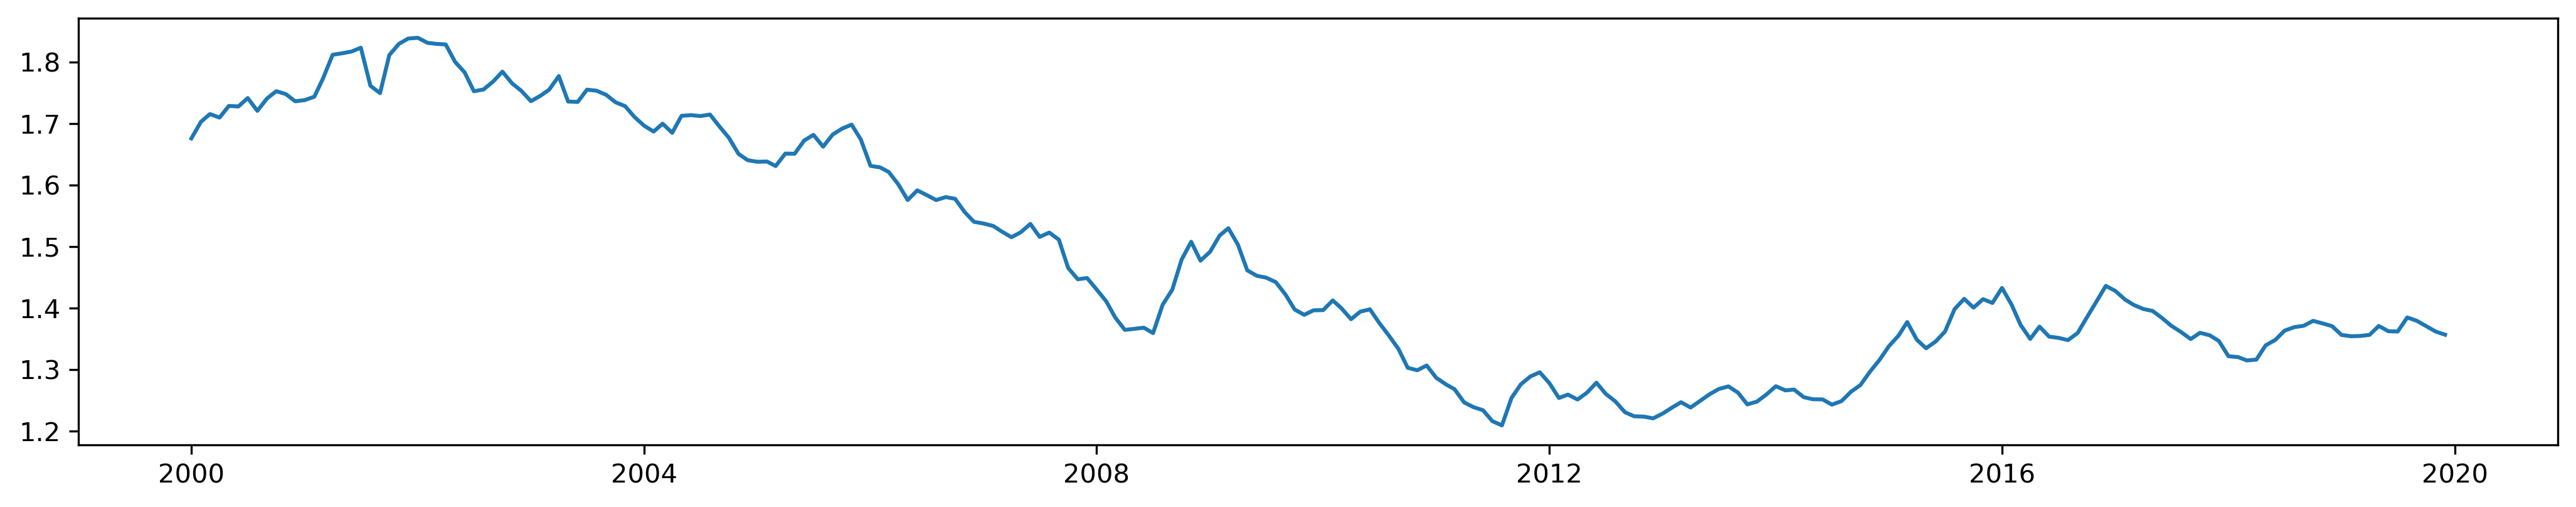

,SGD
Date,
2000-01-01,1.675665
2000-02-01,1.702790
2000-03-01,1.715343
2000-04-01,1.709590
2000-05-01,1.728573
...,...
2019-08-01,1.384495
2019-09-01,1.379000
2019-10-01,1.370445


In [21]:
df_month = df.set_index('Date').resample('M', label='left').mean()  # label left for start date
df_month.index = df_month.index + pd.DateOffset(1)  # starts at 2000-01-03 instead of 2000-01-02
df_SGD_month = df_month[['SGD']]
plt.plot(df_SGD_month)
plt.show()
df_SGD_month

In [22]:
p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]  # time step 12 months, i.e. yearly
optimal_params = None
min_aic = float('inf')

for param in pdq:
    
    for param_seasonal in seasonal_pdq:
        mod = sm.tsa.statespace.SARIMAX(df_SGD_month,
                                        order=param,
                                        seasonal_order=param_seasonal,
                                        enforce_stationarity=False,
                                        enforce_invertibility=False)
        results = mod.fit()
        if results.aic < min_aic:
            optimal_params = [(param), (param_seasonal)]
        min_aic = min(min_aic, results.aic)

        print('SARIMA{}x{} - AIC:{}'.format(param, param_seasonal, results.aic))
    

print(f'Best params: {optimal_params}, min_aic: {min_aic}')
# Best params: [(1, 0, 1), (0, 0, 0, 12)], min_aic: -1267.849491381926

SARIMA(0, 0, 0)x(0, 0, 0, 12) - AIC:871.3224290746846
SARIMA(0, 0, 0)x(0, 0, 1, 12) - AIC:563.6194011098794
SARIMA(0, 0, 0)x(0, 1, 0, 12) - AIC:-542.2467849698546
SARIMA(0, 0, 0)x(0, 1, 1, 12) - AIC:-513.5495460074072
SARIMA(0, 0, 0)x(1, 0, 0, 12) - AIC:-563.3648023583587
SARIMA(0, 0, 0)x(1, 0, 1, 12) - AIC:-559.7805535783018
SARIMA(0, 0, 0)x(1, 1, 0, 12) - AIC:-515.2773029051945
SARIMA(0, 0, 0)x(1, 1, 1, 12) - AIC:-512.0626202200133
SARIMA(0, 0, 1)x(0, 0, 0, 12) - AIC:546.4326713072909
SARIMA(0, 0, 1)x(0, 0, 1, 12) - AIC:255.8085200520398
SARIMA(0, 0, 1)x(0, 1, 0, 12) - AIC:-786.6253243773683
SARIMA(0, 0, 1)x(0, 1, 1, 12) - AIC:-746.7496339133787
SARIMA(0, 0, 1)x(1, 0, 0, 12) - AIC:-808.5198115562102
SARIMA(0, 0, 1)x(1, 0, 1, 12) - AIC:-803.0585639028936
SARIMA(0, 0, 1)x(1, 1, 0, 12) - AIC:-753.4614386568948
SARIMA(0, 0, 1)x(1, 1, 1, 12) - AIC:-747.3545677236785
SARIMA(0, 1, 0)x(0, 0, 0, 12) - AIC:-1248.252840083655
SARIMA(0, 1, 0)x(0, 0, 1, 12) - AIC:-1177.7770157583614
SARIMA(0, 1, 

In [23]:
model_sarima = SARIMAX(df_SGD_month,
                       order=optimal_params[0],
                       seasonal_order=optimal_params[1],   
                       enforce_stationarity=False,
                       enforce_invertibility=False)
results_sarima = model_sarima.fit()
results_sarima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    SGD   No. Observations:                  240
Model:               SARIMAX(1, 0, 1)   Log Likelihood                 636.925
Date:                Sun, 20 Feb 2022   AIC                          -1267.849
Time:                        14:46:53   BIC                          -1257.433
Sample:                    01-01-2000   HQIC                         -1263.651
                         - 12-01-2019                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9989      0.001   1089.454      0.000       0.997       1.001
ma.L1          0.3072      0.060      5.096      0.000       0.189       0.425
sigma2         0.0003   2.01e-05     13.818      0.000       0.000       0.000
===================================================================================
Ljung-Box (Q):                       35.70   Jarque-Bera (JB):                15.10
Prob(Q):                              0.66   Prob(JB):                         0.00
Heteroskedasticity (H):               0.56   Skew:                             0.11
Prob(H) (two-sided):                  0.01   Kurtosis:                         4.21
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

The above model has the lowest AIC score, and the `P>|z|` for all the weights are below 0.05, so it is reasonable to retain all of them in our model.

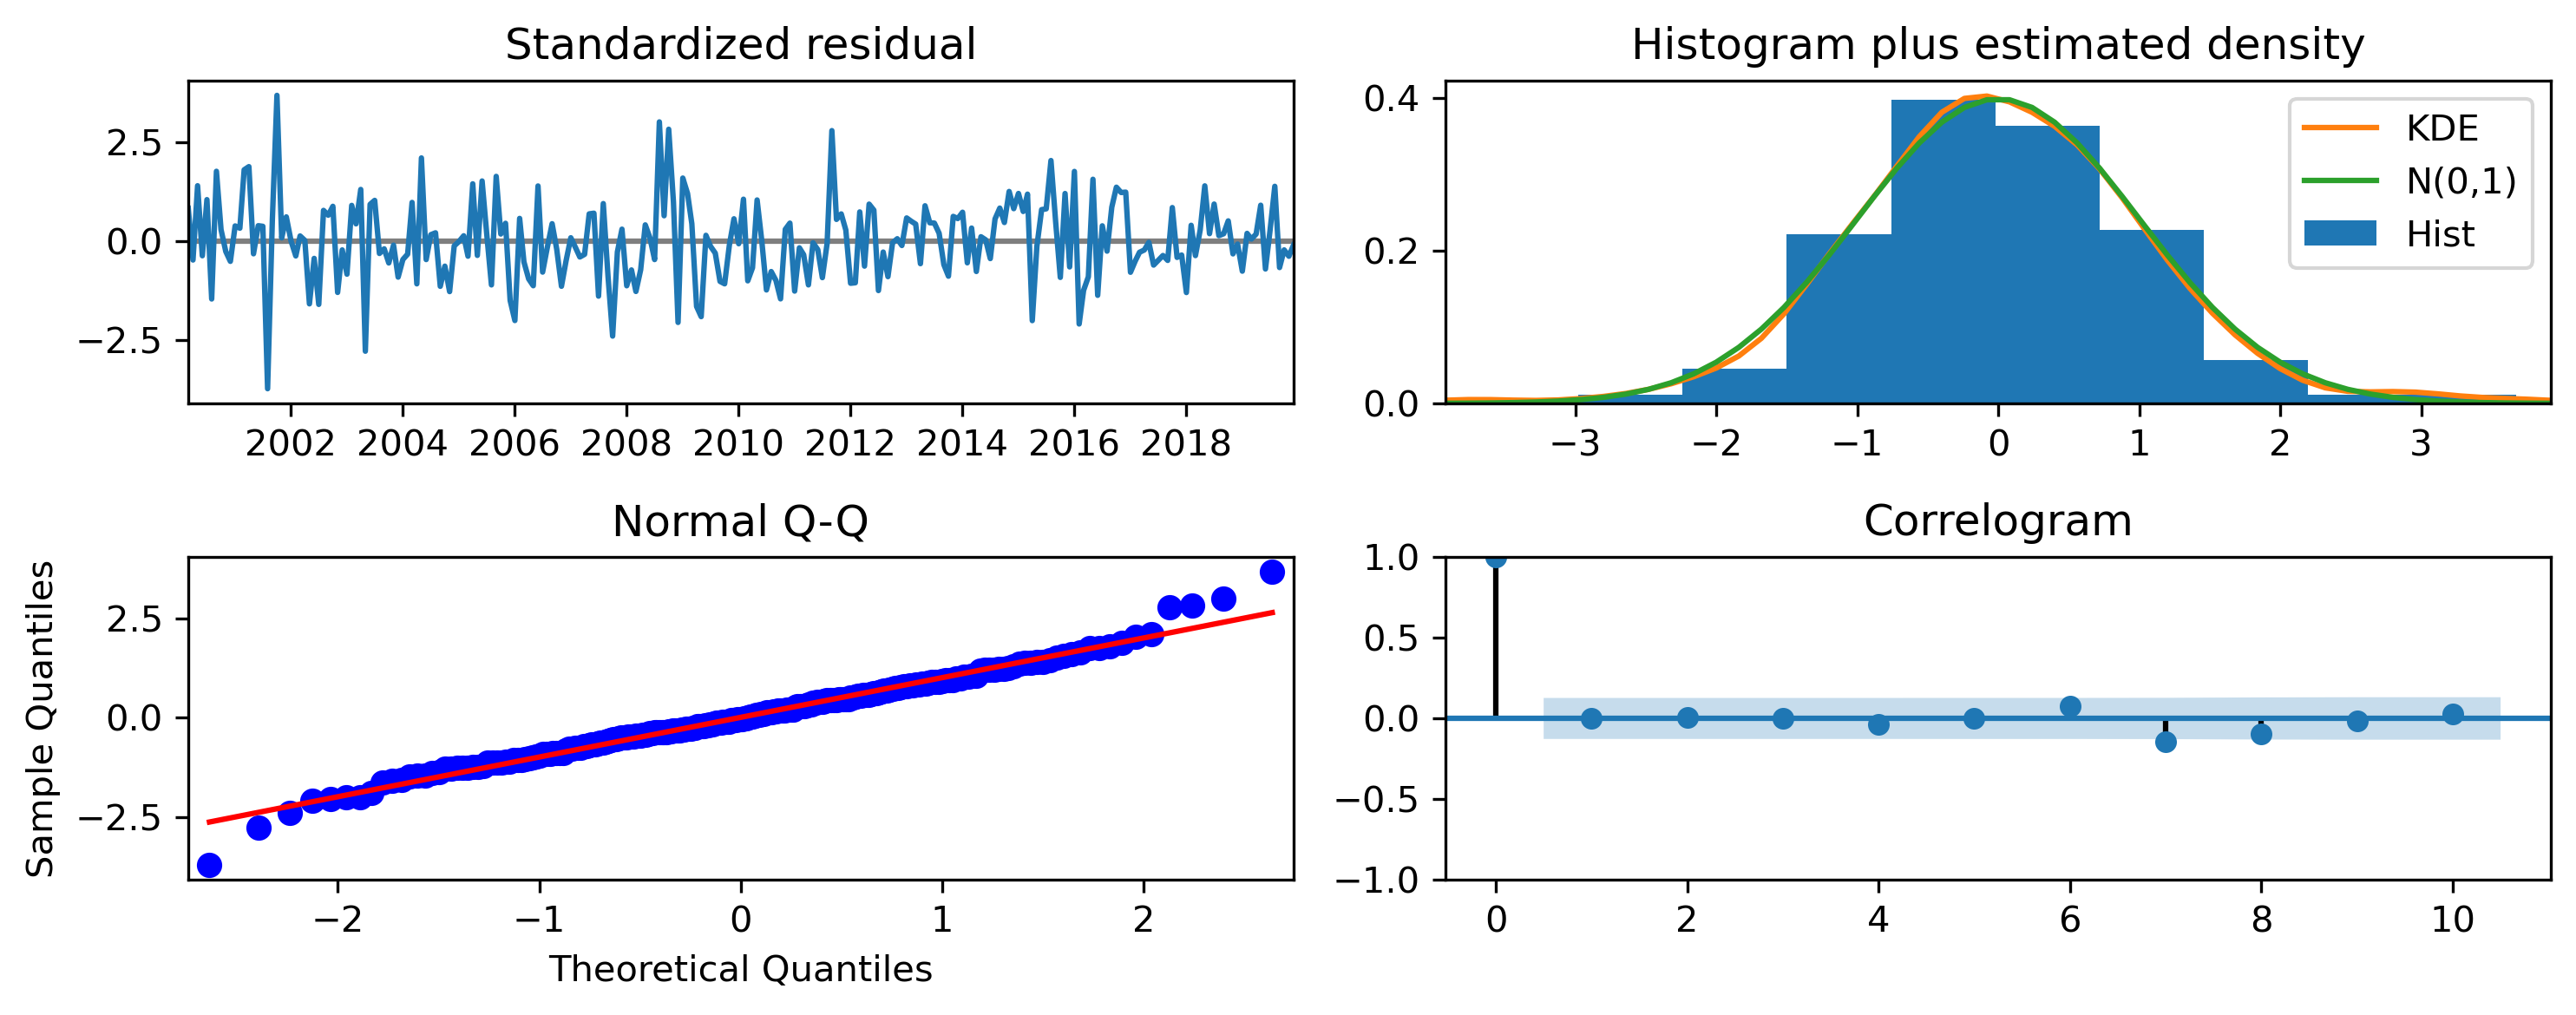

In [24]:
results_sarima.plot_diagnostics(figsize=(10, 4))
plt.tight_layout()

From [machinelearningplus](https://www.machinelearningplus.com/time-series/arima-model-time-series-forecasting-python/),
> Top left: The residual errors seem to fluctuate around a mean of zero and have a uniform variance.

> Top Right: The density plot suggest normal distribution with mean zero.

> Bottom left: All the dots should fall perfectly in line with the red line. Any significant deviations would imply the distribution is skewed.

> Bottom Right: The Correlogram, aka, ACF plot shows the residual errors are not autocorrelated. Any autocorrelation would imply that there is some pattern in the residual errors which are not explained in the model. So you will need to look for more X’s (predictors) to the model.

### Evaluation

In [25]:
train = df_SGD_month[df_SGD_month.index.year < 2019]
test = df_SGD_month[df_SGD_month.index.year == 2019]
len(train), len(test)

(228, 12)

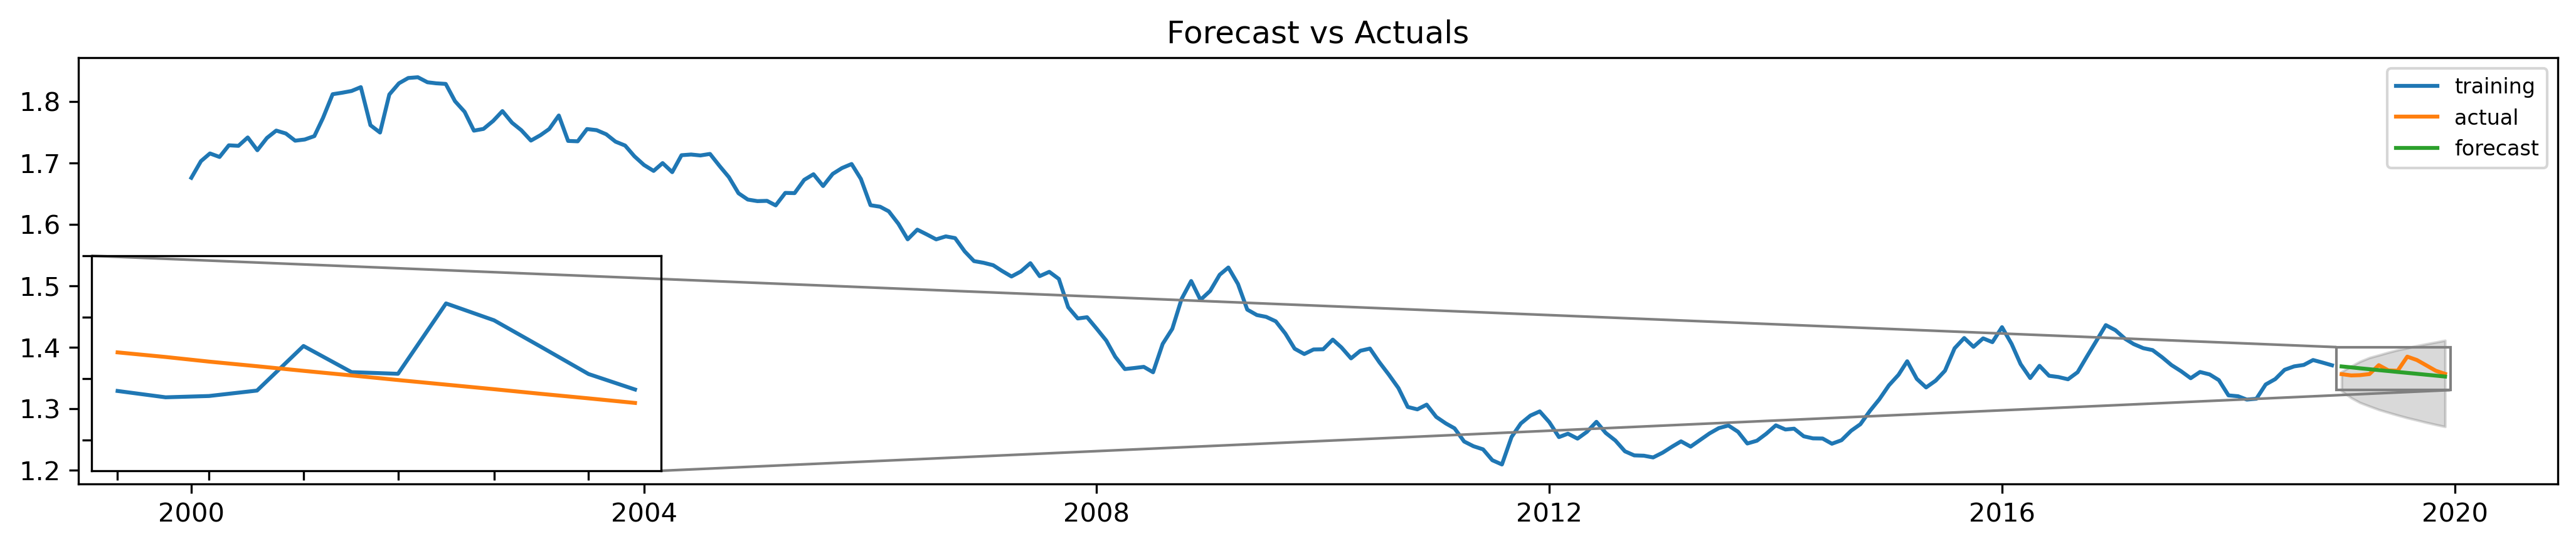

{'mape': 0.00807413551571975,
 'me': -0.003576361866760821,
 'mae': 0.011046888332093127,
 'mpe': -0.002560815265976434,
 'rmse': 0.013260689583396221,
 'acf1': 0.6645433426330642,
 'corr': -0.4268752440054761,
 'minmax': 0.008050800032677441}

In [26]:
_, _, conf_month = fitted_ARIMA.forecast(len(test), alpha=0.05)   # get 95% confidence level for plotting

model = SARIMAX(train,
                order=optimal_params[0],
                seasonal_order=optimal_params[1], 
                enforce_stationarity=False,
                enforce_invertibility=False)  

fitted_SARIMAX = model.fit(disp=-1)  
fc = fitted_SARIMAX.forecast(len(test))
   
plot_forecast(fc.values, conf_month, train, test, ylim=(1.33, 1.4))
results_sarimax = forecast_accuracy(fc.values, test.SGD) # mape = 0.00807
results_sarimax

## Prophet

Prophet is a forecasting tool created by Facebook. Prophet helps to give business users a powerful and easy-to-use tool to help forecast business results without needing to be an expert in time series analysis.

In [27]:
from fbprophet import Prophet

In [28]:
df_prophet = df_SGD.copy()
df_prophet['Date'] = df_SGD.index
df_prophet = df_prophet.rename(columns={'SGD':'y', 'Date':'ds'})
df_prophet

,y,ds
Date,,
2000-01-03,1.658760,2000-01-03
2000-01-10,1.669000,2000-01-10
2000-01-17,1.676575,2000-01-17
2000-01-24,1.693440,2000-01-24
2000-01-31,1.696800,2000-01-31
...,...,...
2019-12-02,1.362880,2019-12-02
2019-12-09,1.357380,2019-12-09
2019-12-16,1.354860,2019-12-16


In [29]:
train = df_prophet[df_prophet.index.year < 2019]
test = df_prophet[df_prophet.index.year == 2019]
len(train), len(test)

(992, 52)

In [30]:
model = Prophet(daily_seasonality=True)
model.fit(train)

In [31]:
future_data = model.make_future_dataframe(periods=52, freq = 'W')
forecast_data = model.predict(future_data)
forecast_data[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1039,2019-12-01,1.366064,1.317639,1.414289
1040,2019-12-08,1.364216,1.314152,1.412517
1041,2019-12-15,1.362838,1.315631,1.411754
1042,2019-12-22,1.361670,1.305605,1.409782
1043,2019-12-29,1.360193,1.309908,1.405441


[]

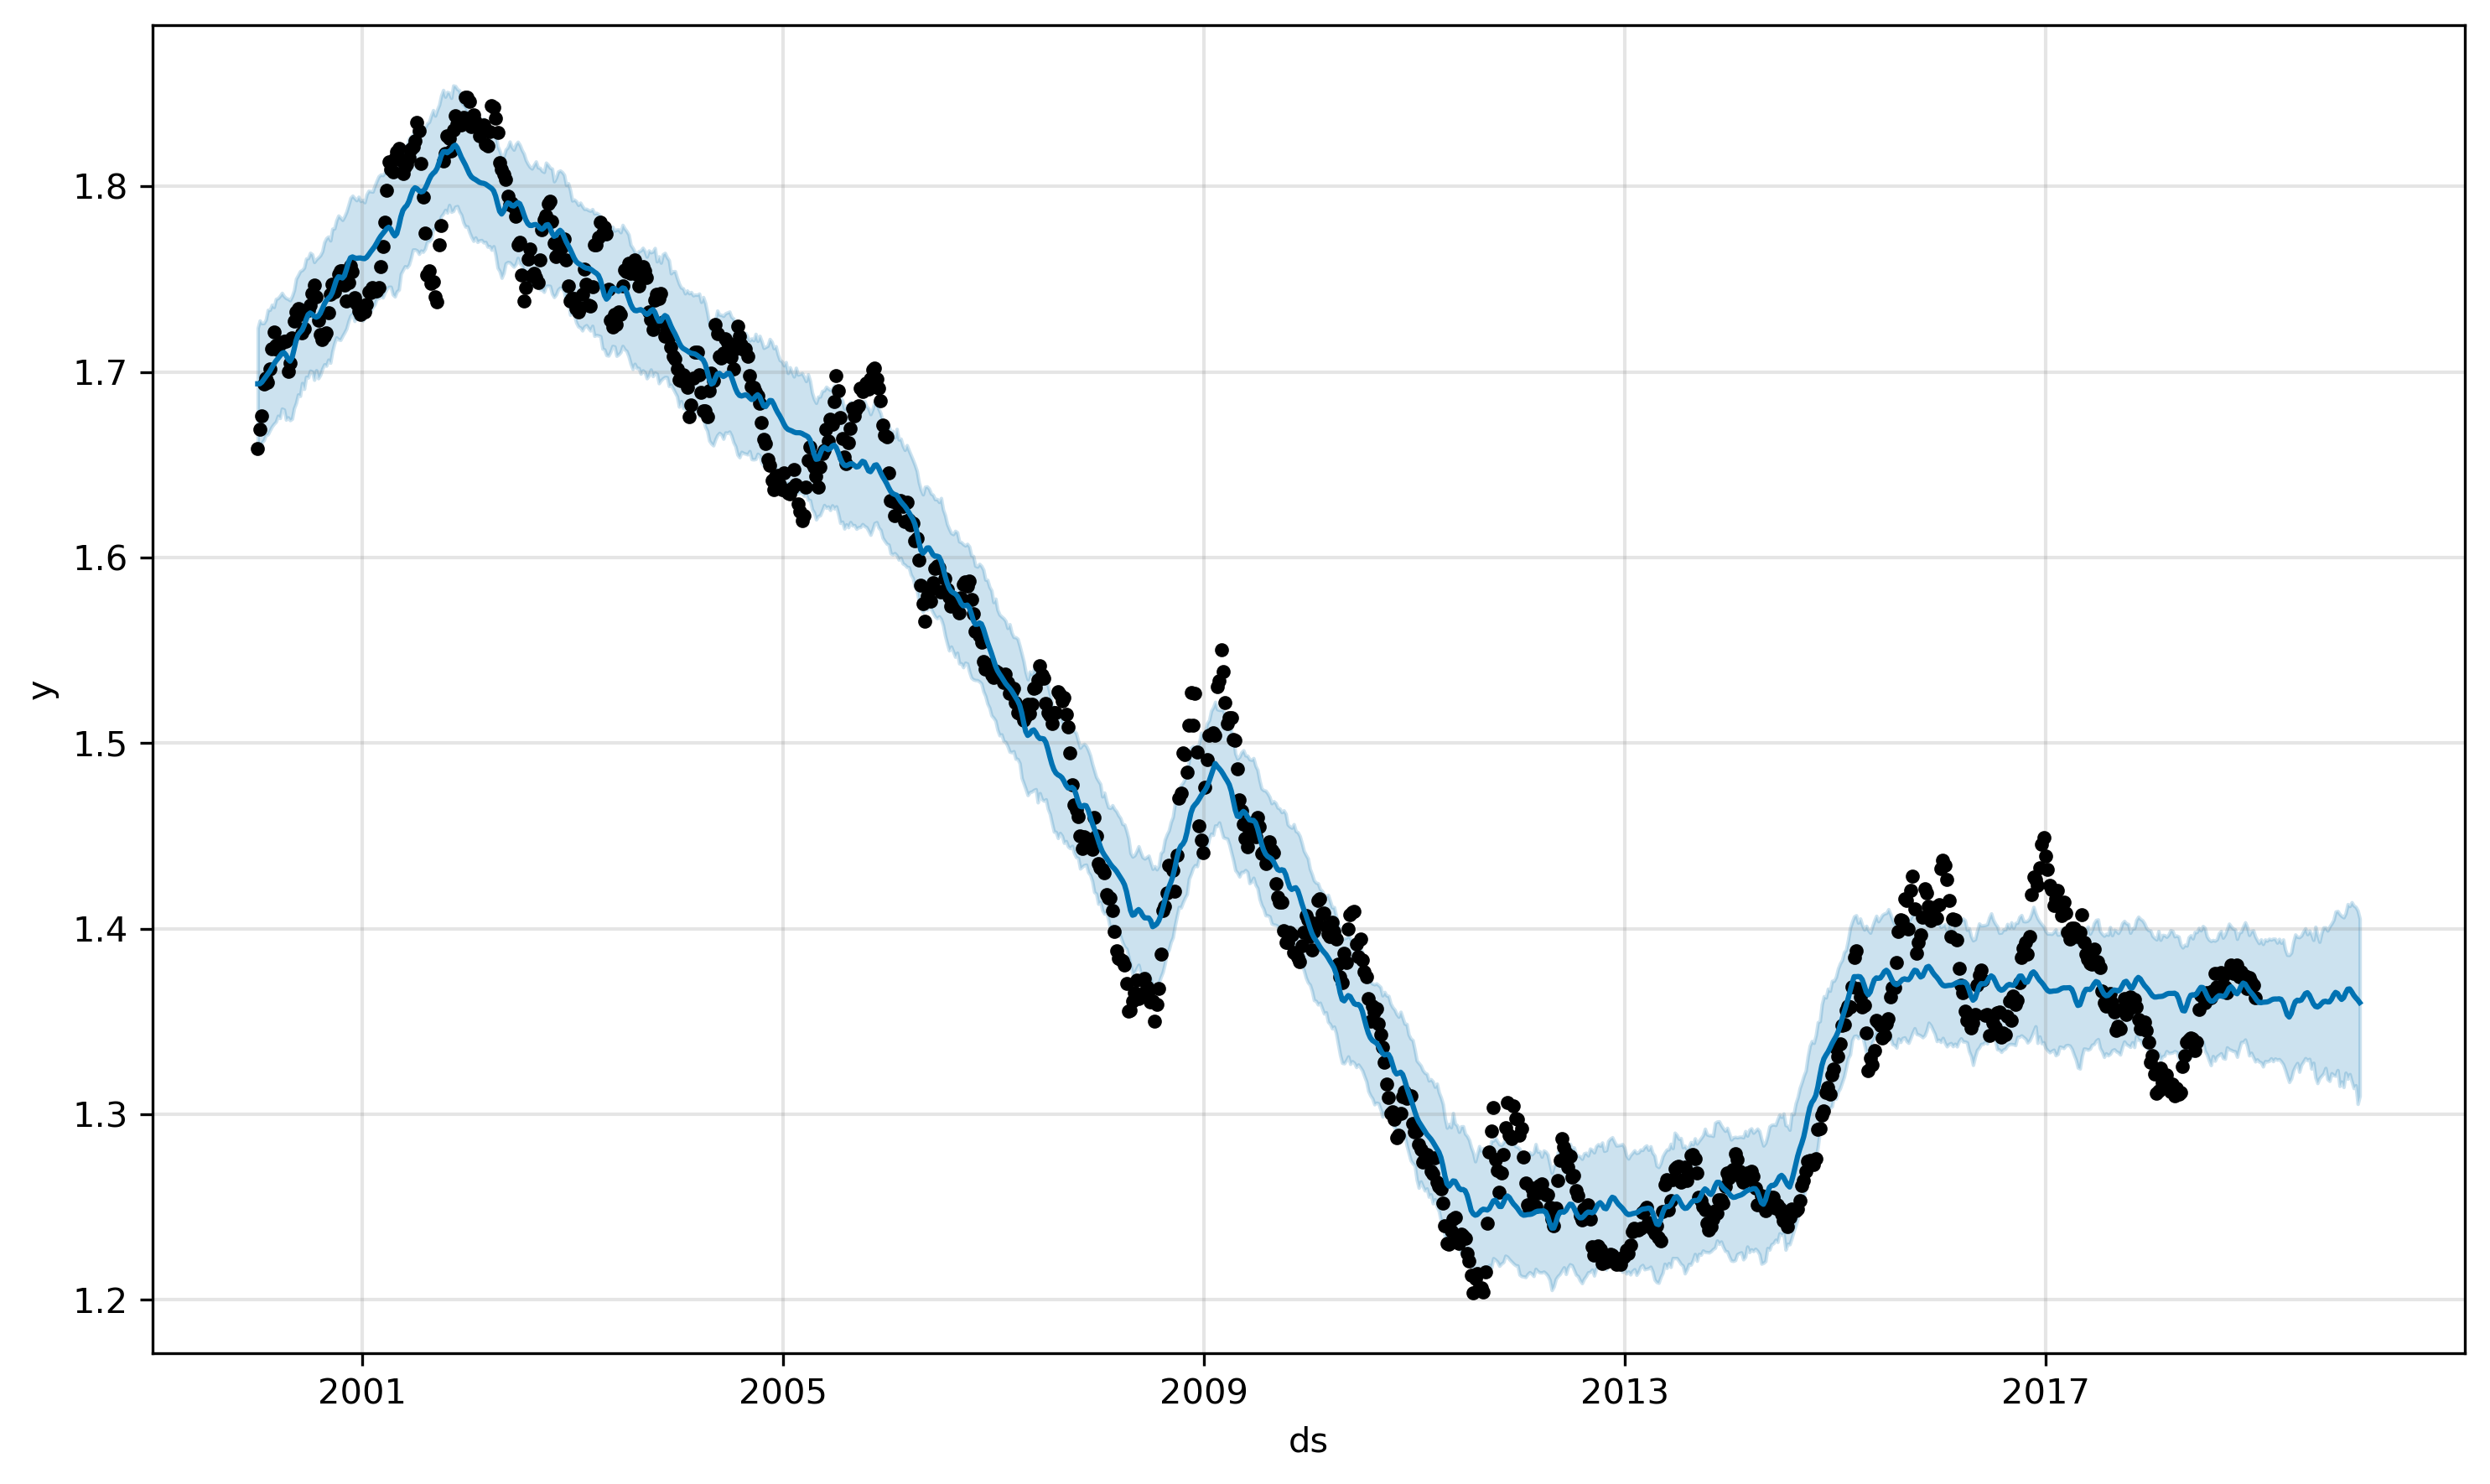

In [32]:
model.plot(forecast_data)
plt.plot(figsize=(10, 3))

[]

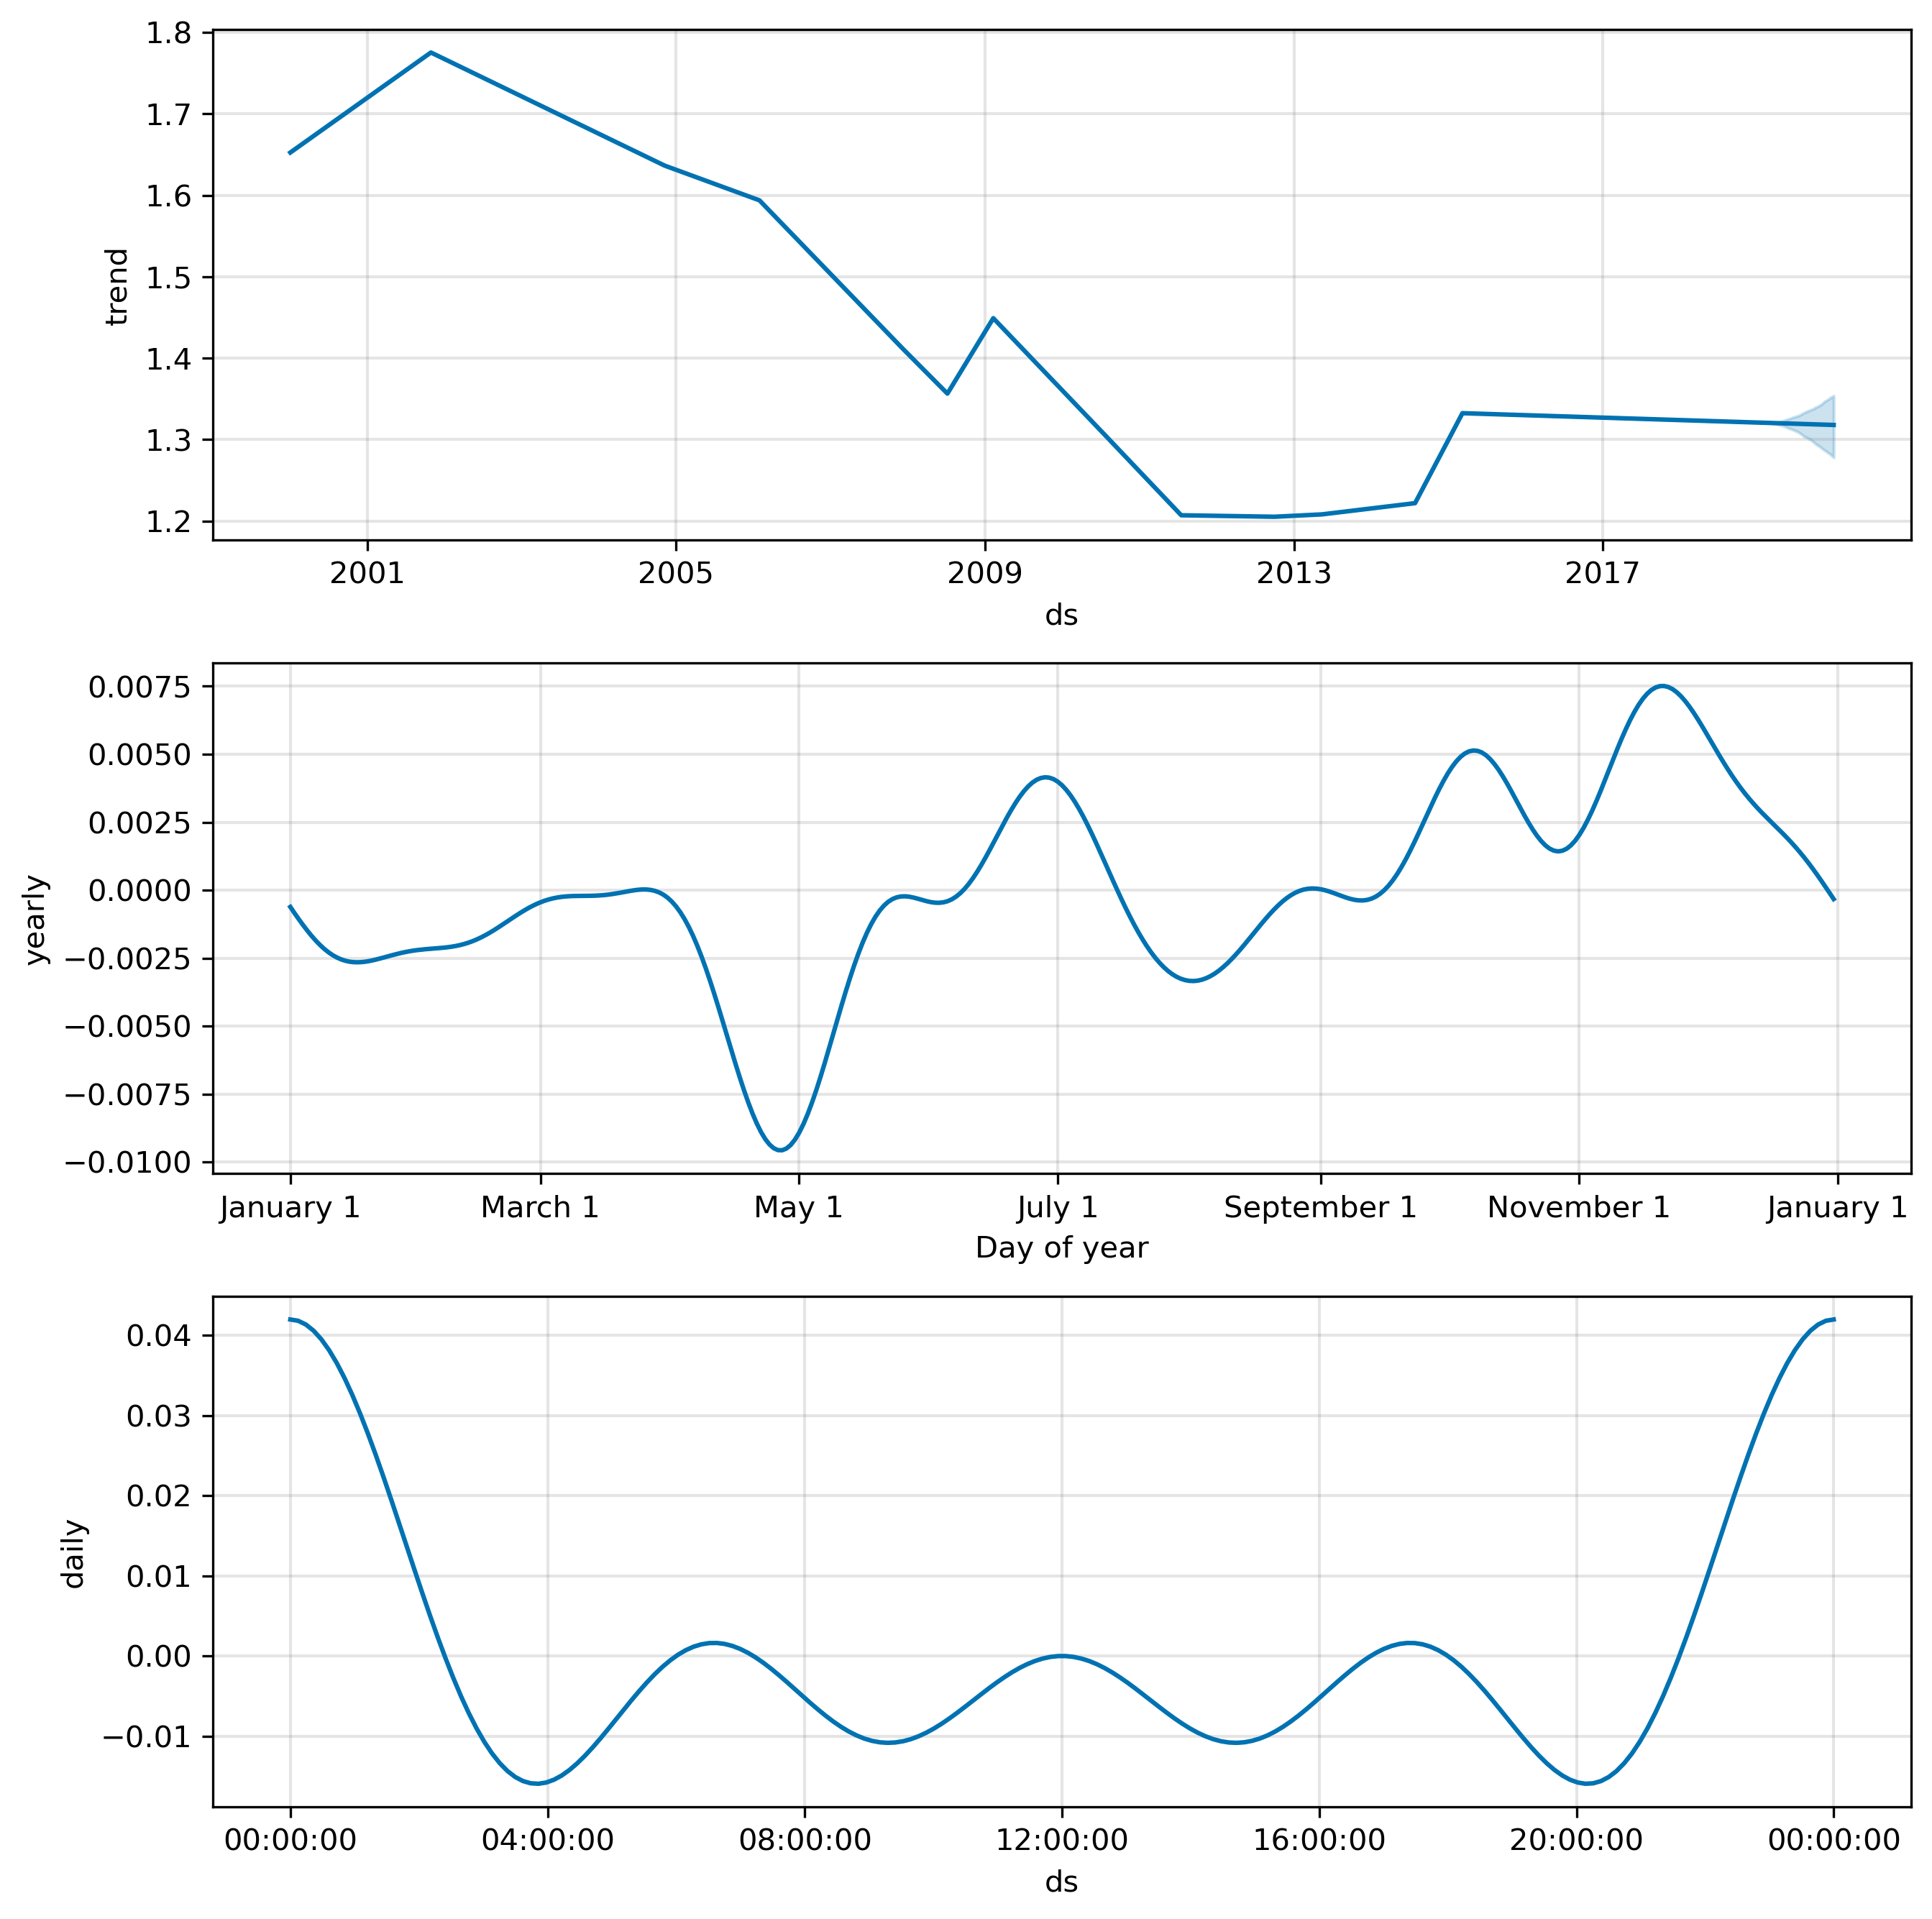

In [33]:
model.plot_components(forecast_data)
plt.plot(figsize=(10, 3))

In [34]:
forecast_yhat = pd.Series(forecast_data.yhat[-len(test):].values, index=test.index)
results_prophet = forecast_accuracy(forecast_yhat, test.y) # 0.00690
results_prophet

{'mape': 0.006904223790134663,
 'me': -0.0024380740382022445,
 'mae': 0.009456039585614072,
 'mpe': -0.001722769327854857,
 'rmse': 0.011804559841758346,
 'acf1': 0.8832969684947813,
 'corr': -0.07408470625229832,
 'minmax': 0.006889188424424542}

# 4. Multivariate Time Series Forecast
## XGBoost

Aside from including the `YUAN` column, we can also create features for XGBoost modelling. We will create some features from the `Date` column.

In [35]:
df_XGB = df_week.copy().reset_index('Date')
df_XGB['quarter'] = df_XGB['Date'].dt.quarter
df_XGB['month'] = df_XGB['Date'].dt.month
df_XGB['year'] = df_XGB['Date'].dt.year
df_XGB['dayofyear'] = df_XGB['Date'].dt.dayofyear
df_XGB['dayofmonth'] = df_XGB['Date'].dt.day
df_XGB['weekofyear'] = df_XGB['Date'].dt.weekofyear
df_XGB.head()

,Date,SGD,YUAN,quarter,month,year,dayofyear,dayofmonth,weekofyear
0,2000-01-03,1.658760,8.279720,1,1,2000,3,3,1
1,2000-01-10,1.669000,8.279600,1,1,2000,10,10,2
2,2000-01-17,1.676575,8.279475,1,1,2000,17,17,3
3,2000-01-24,1.693440,8.278420,1,1,2000,24,24,4
4,2000-01-31,1.696800,8.277860,1,1,2000,31,31,5


We will split the dataset into train test like before.

In [36]:
features = ['YUAN', 'quarter', 'month', 'year', 'dayofyear', 'dayofmonth', 'weekofyear']
train_df = df_XGB[df_XGB.Date.dt.year < 2019]
test_df = df_XGB[df_XGB.Date.dt.year == 2019]

X_train, y_train = train_df[features].values, train_df['SGD'].values
X_test, y_test = test_df[features].values, test_df['SGD'].values
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((992, 7), (992,), (52, 7), (52,))

In [37]:
from xgboost import XGBRegressor
reg = XGBRegressor(n_estimators=500, learning_rate=0.01)
reg.fit(X_train, 
        y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        eval_metric='mae')

[0]	validation_0-mae:0.97640	validation_1-mae:0.85476
[1]	validation_0-mae:0.96669	validation_1-mae:0.84576
[2]	validation_0-mae:0.95707	validation_1-mae:0.83688
[3]	validation_0-mae:0.94755	validation_1-mae:0.82803
[4]	validation_0-mae:0.93812	validation_1-mae:0.81933
[5]	validation_0-mae:0.92878	validation_1-mae:0.81072
[6]	validation_0-mae:0.91953	validation_1-mae:0.80216
[7]	validation_0-mae:0.91038	validation_1-mae:0.79372
[8]	validation_0-mae:0.90132	validation_1-mae:0.78536
[9]	validation_0-mae:0.89235	validation_1-mae:0.77709
[10]	validation_0-mae:0.88347	validation_1-mae:0.76887
[11]	validation_0-mae:0.87468	validation_1-mae:0.76078
[12]	validation_0-mae:0.86598	validation_1-mae:0.75278
[13]	validation_0-mae:0.85736	validation_1-mae:0.74486
[14]	validation_0-mae:0.84883	validation_1-mae:0.73696
[15]	validation_0-mae:0.84038	validation_1-mae:0.72919
[16]	validation_0-mae:0.83202	validation_1-mae:0.72151
[17]	validation_0-mae:0.82373	validation_1-mae:0.71384
[18]	validation_0-ma

XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
             importance_type='gain', interaction_constraints='',
             learning_rate=0.01, max_delta_step=0, max_depth=6,
             min_child_weight=1, missing=nan, monotone_constraints='()',
             n_estimators=500, n_jobs=0, num_parallel_tree=1, random_state=0,
             reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
             tree_method='exact', validate_parameters=1, verbosity=None)

In [38]:
predictions = reg.predict(X_test)
test_df['predictions'] = (predictions)
test_df.head()

,Date,SGD,YUAN,quarter,month,year,dayofyear,dayofmonth,weekofyear,predictions
992,2019-01-07,1.354300,6.812160,1,1,2019,7,7,2,1.366371
993,2019-01-14,1.356275,6.765675,1,1,2019,14,14,3,1.364081
994,2019-01-21,1.358175,6.781300,1,1,2019,21,21,4,1.364004
995,2019-01-28,1.350440,6.724800,1,1,2019,28,28,5,1.354835
996,2019-02-04,1.354340,6.742600,1,2,2019,35,4,6,1.361095


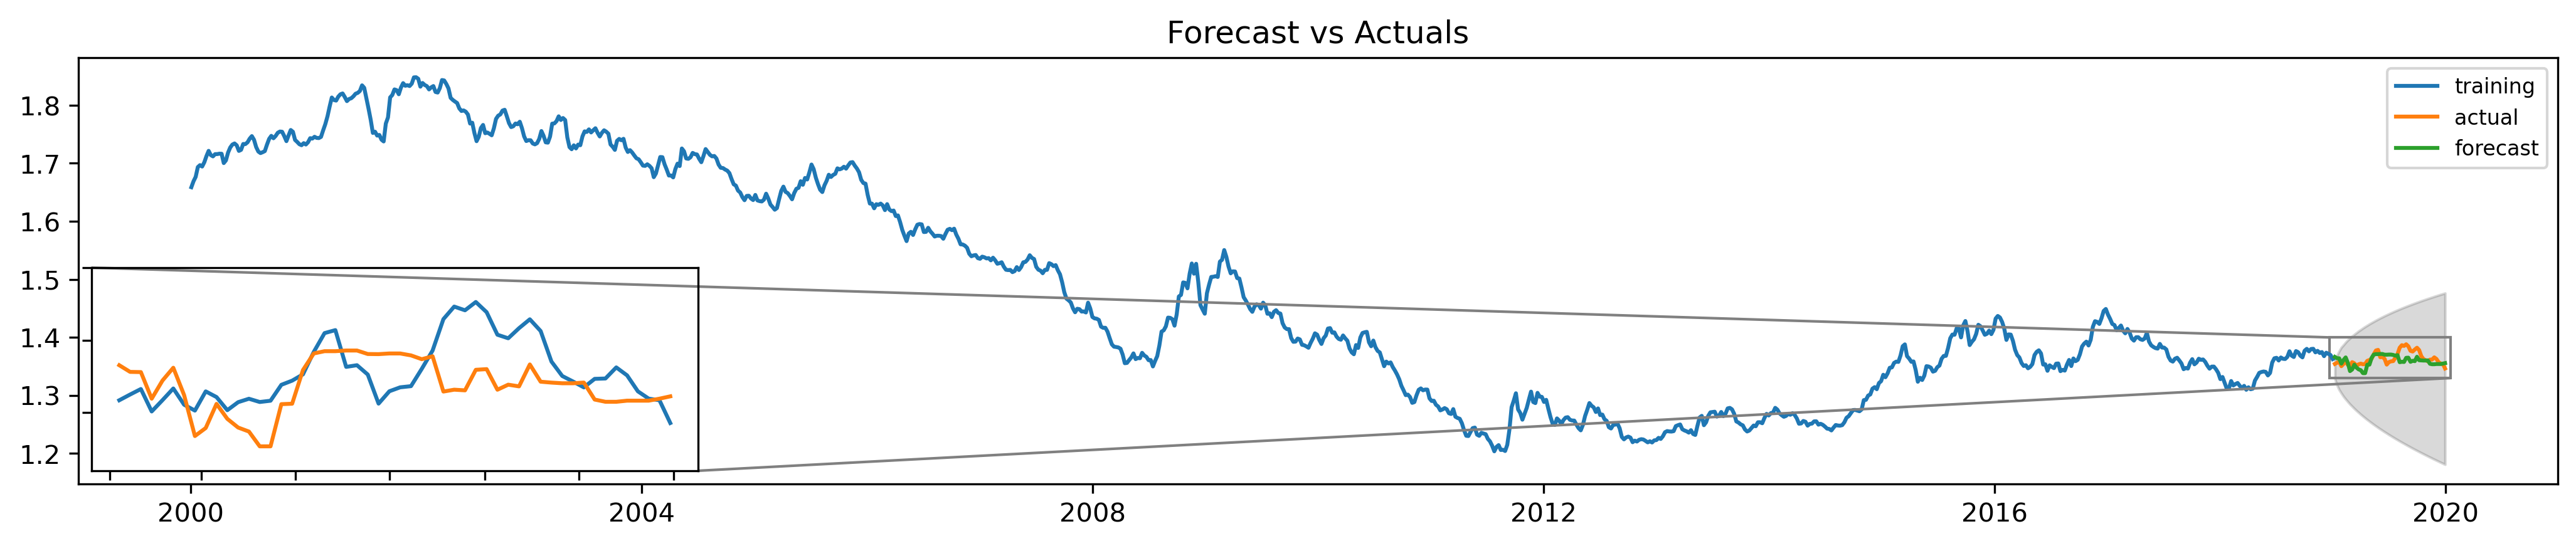

In [39]:
plot_forecast(predictions, conf_week, train_df.set_index('Date').SGD, test_df.set_index('Date').SGD, ylim=(1.33, 1.4))

In [40]:
results_XGB = forecast_accuracy(predictions, y_test)  # 0.00708
results_XGB

{'mape': 0.007085260665645475,
 'me': -0.004556359251951563,
 'mae': 0.009696111445304693,
 'mpe': -0.003297239752728489,
 'rmse': 0.01202890730763982,
 'acf1': 0.8146217765439098,
 'corr': 0.3819100397387236,
 'minmax': 0.007071936265524714}

# 5. Comparison

We will plot the metrics for all 4 models.

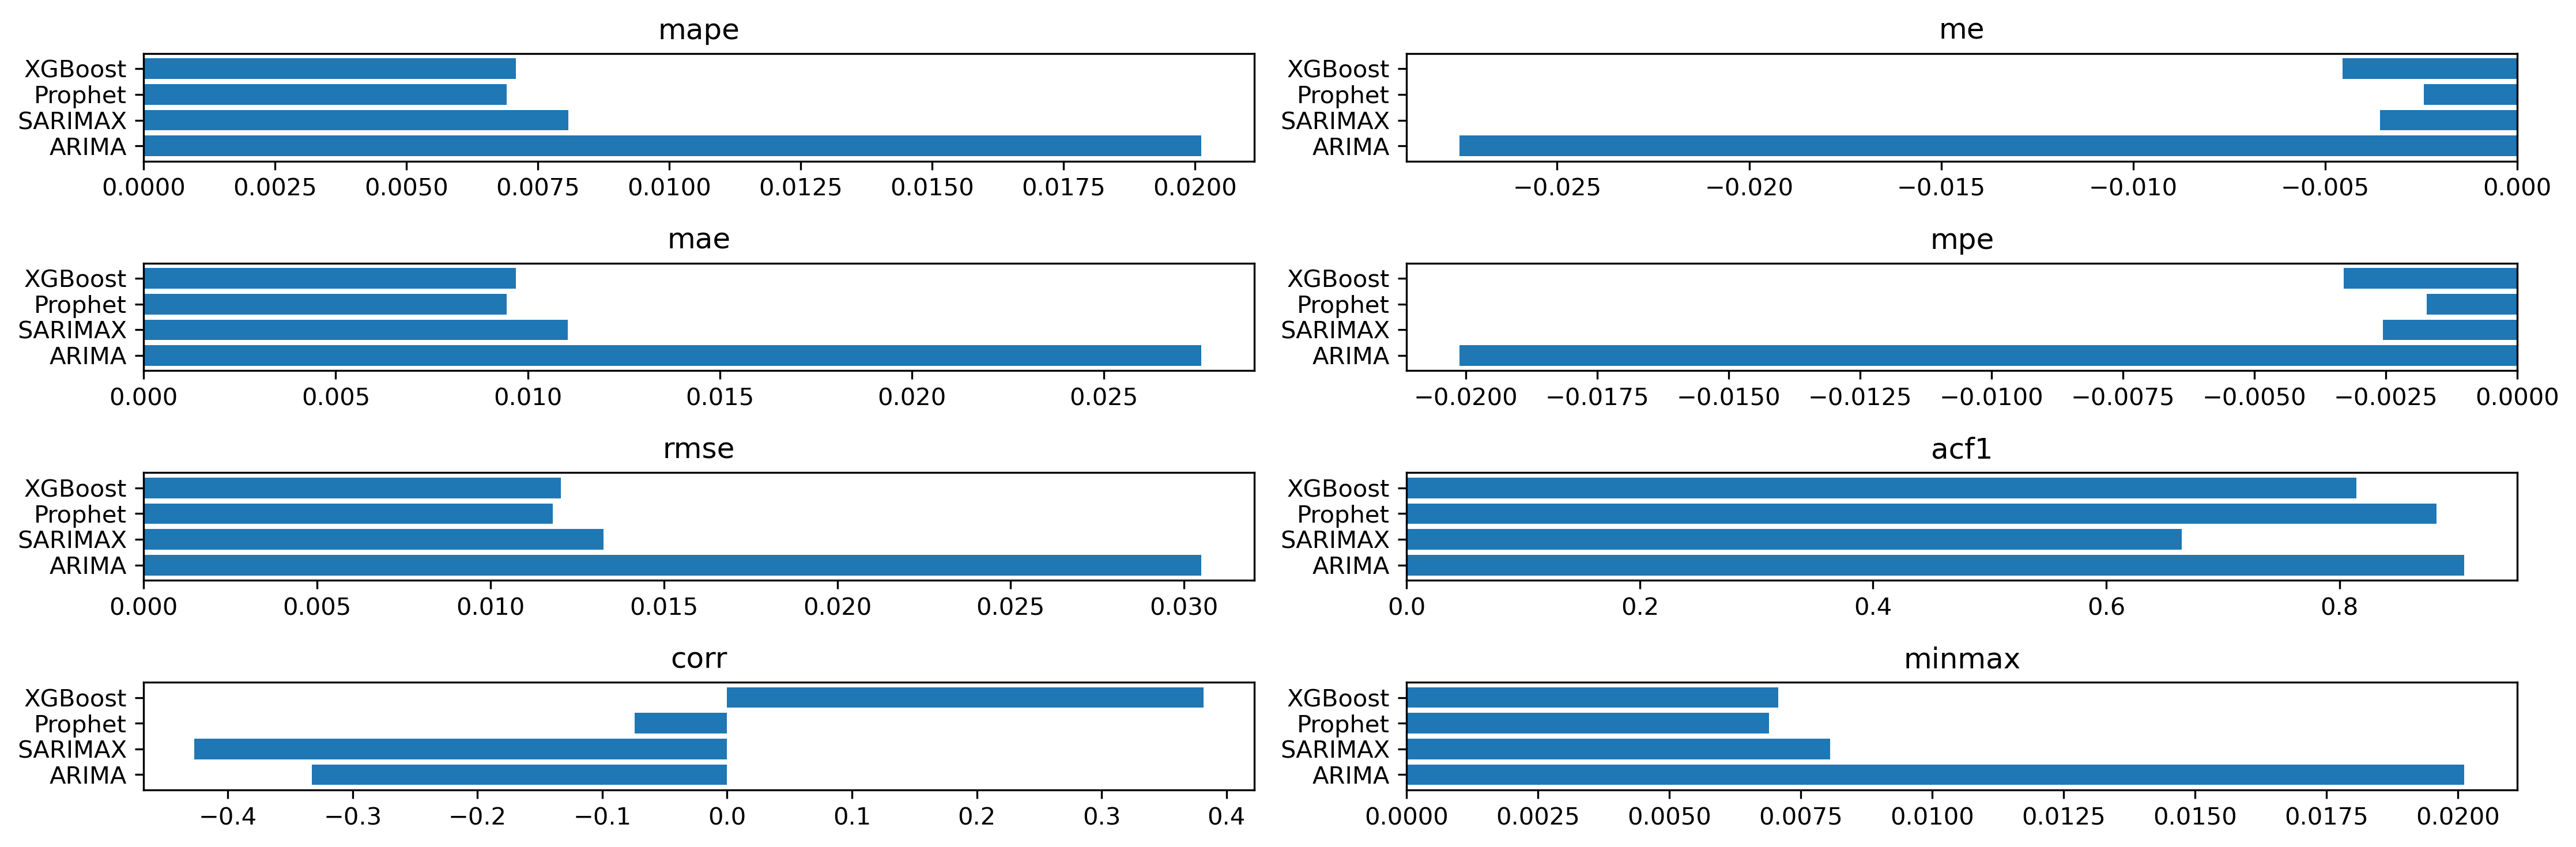

In [41]:
metrics = ['mape', 'me', 'mae', 'mpe', 'rmse', 'acf1', 'corr', 'minmax']
models = ['ARIMA', 'SARIMAX', 'Prophet', 'XGBoost']

fig, nested_ax = plt.subplots(4, 2, figsize=(15,5))
axes = [c for r in nested_ax for c in r]  # flatten ax for easy loop

for metric, ax in zip(metrics, axes):
    scores = [results_arima[metric], 
              results_sarimax[metric], 
              results_prophet[metric], 
              results_XGB[metric]]

    ax.barh(models, scores)
    ax.set_title(f'{metric}')
plt.tight_layout()

From the plot, Prophet seems to be the best performing model out of all four models. This is surprising since XGBoost uses a multivariate dataset that includes the `YUAN` column. For further studies, XGBoost model can be improved with more hyperparameter tuning, which can potentially beat the other models. Both ARIMA and SARIMA have been around for a long time can produce respectable results without a machine learning approach. However, both may require extensive amounts of parameter tuning.

# 6. Conclusion

We have went through four different time series forecast methods for predict SGD/USD exchange rates. Throughout this case study, it can be seen that balance between quality and cost is important. Both the ARIMA and SARIMA model can produce spectacular results after tuning but can require many hours of tuning and time series manipulation, whereas a Prophet model can be built easily and can achieve comparable results.
